# **Setup & Importing Libraries**

In [2]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setting visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# **Loading the Data**

In [3]:
# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/std_dropout_prediction_project/data/raw/predict_student_dropout_academic_success_raw.csv', sep=';')
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


# **Initial Data Audit (Shape & Info)**

In [4]:
print("--- Dataset Shape ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n--- First 5 Rows ---")
display(df.head())

print("\n--- Data Types & Missing Values Overview ---")
df.info()

--- Dataset Shape ---
Rows: 4424, Columns: 37

--- First 5 Rows ---


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate



--- Data Types & Missing Values Overview ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  


In [5]:
# 1. Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())


# 2. Check value ranges

# Admission grade should be between 0 and 200
invalid_admission = df[
    (df["Admission grade"] < 0) | (df["Admission grade"] > 200)
]

print("\nInvalid Admission Grade values:")
print(invalid_admission[["Admission grade"]])


# Semester grades should be between 0 and 20
semester_grade_columns = [
    "Curricular units 1st sem (grade)",
    "Curricular units 2nd sem (grade)"
]

for col in semester_grade_columns:
    invalid_grades = df[
        (df[col] < 0) | (df[col] > 20)
    ]

    print(f"\nInvalid values in {col}:")
    print(invalid_grades[[col]])


# 3. Check for duplicate rows
duplicates = df[df.duplicated()]

print("\nNumber of duplicate rows:", df.duplicated().sum())
print("Duplicate rows:")
print(duplicates)

Missing values in each column:
Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance\t                      0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder               



*   No missing values
*   No invalid ranges
*   No duplicates




# **Decoding Categorical Variables**

In [6]:
# Preserving original data
RAW = df.copy()
df = df.copy()

# Stripping whitespace from column names
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP', 'Target']


In [7]:
# Renamimg known typo safely
# The original dataset uses "Nacionality" instead of "Nationality"
if 'Nacionality' in df.columns and 'Nationality' not in df.columns:
    df = df.rename(columns={'Nacionality': 'Nationality'})

elif 'Nacionality' in df.columns and 'Nationality' in df.columns:
    print('Warning: Both Nacionality and Nationality exist. Inspect manually.')

In [8]:
# Defining mapping dictionaries
marital_map = {
    1: "Single",
    2: "Married",
    3: "Widower",
    4: "Divorced",
    5: "De Facto Union",
    6: "Legally Separated"
}

gender_map = {
    0: "Female",
    1: "Male"
}

attendance_map = {
    0: "Evening",
    1: "Daytime"
}

yes_no_map = {
    0: "No",
    1: "Yes"
}

course_map = {
    33: "Biofuel Production Technologies",
    171: "Animation and Multimedia Design",
    8014: "Social Service (Evening Attendance)",
    9003: "Agronomy",
    9070: "Communication Design",
    9085: "Veterinary Nursing",
    9119: "Informatics Engineering",
    9130: "Equiniculture",
    9147: "Management",
    9238: "Social Service",
    9254: "Tourism",
    9500: "Nursing",
    9556: "Oral Hygiene",
    9670: "Advertising and Marketing Management",
    9773: "Journalism and Communication",
    9853: "Basic Education",
    9991: "Management (Evening Attendance)"
}

nationality_map = {
    1: "Portuguese",
    2: "German",
    6: "Spanish",
    11: "Italian",
    13: "Dutch",
    14: "English",
    17: "Lithuanian",
    21: "Angolan",
    22: "Cape Verdean",
    24: "Guinean",
    25: "Mozambican",
    26: "Santomean",
    32: "Turkish",
    41: "Brazilian",
    62: "Romanian",
    100: "Moldova (Republic of)",
    101: "Mexican",
    103: "Ukrainian",
    105: "Russian",
    108: "Cuban",
    109: "Colombian"
}

application_mode_map = {
    1: "1st Phase - General Contingent",
    2: "Ordinance No. 612/93",
    5: "1st Phase - Special Contingent (Azores Island)",
    7: "Holders of Other Higher Courses",
    10: "Ordinance No. 854-B/99",
    15: "International Student (Bachelor)",
    16: "1st Phase - Special Contingent (Madeira Island)",
    17: "2nd Phase - General Contingent",
    18: "3rd Phase - General Contingent",
    26: "Ordinance No. 533-A/99, Item B2 (Different Plan)",
    27: "Ordinance No. 533-A/99, Item B3 (Other Institution)",
    39: "Over 23 Years Old",
    42: "Transfer",
    43: "Change of Course",
    44: "Technological Specialization Diploma Holders",
    51: "Change of Institution/Course",
    53: "Short Cycle Diploma Holders",
    57: "Change of Institution/Course (International)"
}

prev_qualification_map = {
    1: "Secondary Education",
    2: "Higher Education - Bachelor's Degree",
    3: "Higher Education - Degree",
    4: "Higher Education - Master's Degree",
    5: "Higher Education - Doctorate",
    6: "Frequency of Higher Education",
    9: "12th Year of Schooling - Not Completed",
    10: "11th Year of Schooling - Not Completed",
    12: "Other - 11th Year of Schooling",
    14: "10th Year of Schooling",
    15: "10th Year of Schooling - Not Completed",
    19: "Basic Education 3rd Cycle (9th/10th/11th Year) or Equivalent",
    38: "Basic Education 2nd Cycle (6th/7th/8th Year) or Equivalent",
    39: "Technological Specialization Course",
    40: "Higher Education - Degree (1st Cycle)",
    42: "Professional Higher Technical Course",
    43: "Higher Education - Master (2nd Cycle)"
}

mother_qualification_map = {
    1: "Secondary Education - 12th Year of Schooling or Equivalent",
    2: "Higher Education - Bachelor's Degree",
    3: "Higher Education - Degree",
    4: "Higher Education - Master's",
    5: "Higher Education - Doctorate",
    6: "Frequency of Higher Education",
    9: "12th Year of Schooling - Not Completed",
    10: "11th Year of Schooling - Not Completed",
    11: "7th Year (Old)",
    12: "Other - 11th Year of Schooling",
    14: "10th Year of Schooling",
    18: "General Commerce Course",
    19: "Basic Education 3rd Cycle (9th/10th/11th Year) or Equivalent",
    22: "Technical-Professional Course",
    26: "7th Year of Schooling",
    27: "2nd Cycle of General High School",
    29: "9th Year of Schooling - Not Completed",
    30: "8th Year of Schooling",
    34: "Unknown",
    35: "Can't Read or Write",
    36: "Can Read Without 4th Year of Schooling",
    37: "Basic Education 1st Cycle (4th/5th Year) or Equivalent",
    38: "Basic Education 2nd Cycle",
    39: "Technological Specialization Course",
    40: "Higher Education - Degree (1st Cycle)",
    41: "Specialized Higher Studies Course",
    42: "Professional Higher Technical Course",
    43: "Higher Education - Master (2nd Cycle)",
    44: "Higher Education - Doctorate (3rd Cycle)"
}

# Father's qualifications inherits from Mother's, adding unique Father keys
father_qualification_map = mother_qualification_map.copy()
father_qualification_map.update({
    13: "2nd Year Complementary High School",
    20: "Complementary High School Course",
    25: "Complementary High School - Not Concluded",
    31: "General Course of Administration and Commerce",
    33: "Supplementary Accounting and Administration"
})

mother_occupation_map = {
    0: "Student",
    1: "Legislative/Executive Directors & Managers",
    2: "Intellectual & Scientific Specialists",
    3: "Intermediate Level Technicians & Professions",
    4: "Administrative Staff",
    5: "Personal Services, Security, & Sellers",
    6: "Farmers & Skilled Agriculture, Fisheries, & Forestry",
    7: "Skilled Industry, Construction, & Craftsmen",
    8: "Machine Operators & Assembly Workers",
    9: "Unskilled Workers",
    10: "Armed Forces Professions",
    90: "Other Situation",
    99: "Not Reported (Blank)",
    122: "Health Professionals",
    123: "Teachers",
    125: "ICT Specialists",
    131: "Intermediate Science & Engineering Technicians",
    132: "Intermediate Health Technicians & Professionals",
    134: "Intermediate Legal, Social, & Cultural Technicians",
    141: "Office Workers & Secretaries",
    143: "Data, Accounting, & Financial Operators",
    144: "Other Administrative Support Staff",
    151: "Personal Service Workers",
    152: "Sellers",
    153: "Personal Care Workers",
    171: "Skilled Construction Workers",
    173: "Skilled Printing, Jewelers, & Artisans",
    175: "Food Processing, Woodworking, & Clothing Workers",
    191: "Cleaning Workers",
    192: "Unskilled Agriculture, Animal, Fisheries, & Forestry",
    193: "Unskilled Extractive, Construction, & Transport Workers",
    194: "Meal Preparation Assistants"
}

# Father's occupations inherits from Mother's, adding unique Father keys
father_occupation_map = mother_occupation_map.copy()
father_occupation_map.update({
    101: "Armed Forces Officers",
    102: "Armed Forces Sergeants",
    103: "Other Armed Forces Personnel",
    112: "Directors of Administrative & Commercial Services",
    114: "Hotel, Catering, Trade, & Services Directors",
    121: "Physical Sciences, Math, & Engineering Specialists",
    124: "Finance, Accounting, & PR Specialists",
    135: "ICT Technicians",
    154: "Protection & Security Services Personnel",
    161: "Market-Oriented Farmers & Agricultural Workers",
    163: "Subsistence Farmers, Fishermen, & Hunters",
    172: "Skilled Metallurgy & Metalworking Workers",
    174: "Skilled Electricity & Electronics Workers",
    181: "Fixed Plant & Machine Operators",
    182: "Assembly Workers",
    183: "Vehicle Drivers & Mobile Equipment Operators",
    195: "Street Vendors & Service Providers"
})

In [9]:
# Converting coded columns to nullable integer
coded_columns = [
    'Marital status',
    'Application mode',
    'Application order',
    'Course',
    'Daytime/evening attendance',
    'Previous qualification',
    'Nationality',
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    'Displaced',
    'Educational special needs',
    'Debtor',
    'Tuition fees up to date',
    'Gender',
    'Scholarship holder',
    'International'
]

for col in coded_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')
    else:
        print(f'Warning: column not found: {col}')

In [10]:
# Creating a safe decoding function
STRICT = False

mapping_report = []

def decode_column(
    data,
    col,
    mapping,
    out_col=None,
    strict=True,
    unknown_label='UNMAPPED - CHECK'
):
    """
    Maps coded values to readable labels while checking for unmapped values.

    If strict=True, stops when unmapped values are found.
    If strict=False, labels unmapped values as unknown_label and logs them.
    """

    if out_col is None:
        out_col = col

    if col not in data.columns:
        print(f'⚠️ Column not found: {col}')

        mapping_report.append({
            'column': col,
            'status': 'column missing',
            'unmapped': [],
            'nulls_before': None,
            'nulls_after': None
        })

        return data

    s = data[col]

    nulls_before = int(s.isna().sum())

    unique_values = set(s.dropna().unique())
    mapping_keys = set(mapping.keys())

    unmapped = sorted(unique_values - mapping_keys, key=str)

    record = {
        'column': col,
        'status': 'ok',
        'unmapped': unmapped,
        'nulls_before': nulls_before,
        'nulls_after': None
    }

    if unmapped:
        print(f'❌ {col} has unmapped values: {unmapped}')

        if strict:
            mapping_report.append(record)
            raise ValueError(
                f'Unmapped values found in {col}. '
                f'Fix the mapping or explicitly decide how to handle them.'
            )

    mapped = s.map(mapping)

    if (not strict) and unmapped:
        mapped = mapped.copy()
        unmapped_mask = s.notna() & ~s.isin(mapping_keys)
        mapped[unmapped_mask] = unknown_label

    data[out_col] = mapped

    record['nulls_after'] = int(data[out_col].isna().sum())

    mapping_report.append(record)

    print(f'✅ Decoded {col} -> {out_col}. Nulls after: {record["nulls_after"]}')

    return data

In [11]:
# Applying the decoding
df = decode_column(df, 'Marital status', marital_map, strict=STRICT)

df = decode_column(df, 'Gender', gender_map, strict=STRICT)

df = decode_column(df, 'Daytime/evening attendance', attendance_map, strict=STRICT)

binary_cols = [
    'Displaced',
    'Educational special needs',
    'Debtor',
    'Tuition fees up to date',
    'Scholarship holder',
    'International'
]

for col in binary_cols:
    df = decode_column(df, col, yes_no_map, strict=STRICT)

df = decode_column(df, 'Course', course_map, strict=STRICT)

df = decode_column(df, 'Nationality', nationality_map, strict=STRICT)

df = decode_column(df, 'Application mode', application_mode_map, strict=STRICT)

df = decode_column(df, 'Previous qualification', prev_qualification_map, strict=STRICT)

df = decode_column(df, "Mother's qualification", mother_qualification_map, strict=STRICT)

df = decode_column(df, "Father's qualification", father_qualification_map, strict=STRICT)

df = decode_column(df, "Mother's occupation", mother_occupation_map, strict=STRICT)

df = decode_column(df, "Father's occupation", father_occupation_map, strict=STRICT)

✅ Decoded Marital status -> Marital status. Nulls after: 0
✅ Decoded Gender -> Gender. Nulls after: 0
✅ Decoded Daytime/evening attendance -> Daytime/evening attendance. Nulls after: 0
✅ Decoded Displaced -> Displaced. Nulls after: 0
✅ Decoded Educational special needs -> Educational special needs. Nulls after: 0
✅ Decoded Debtor -> Debtor. Nulls after: 0
✅ Decoded Tuition fees up to date -> Tuition fees up to date. Nulls after: 0
✅ Decoded Scholarship holder -> Scholarship holder. Nulls after: 0
✅ Decoded International -> International. Nulls after: 0
✅ Decoded Course -> Course. Nulls after: 0
✅ Decoded Nationality -> Nationality. Nulls after: 0
✅ Decoded Application mode -> Application mode. Nulls after: 0
✅ Decoded Previous qualification -> Previous qualification. Nulls after: 0
✅ Decoded Mother's qualification -> Mother's qualification. Nulls after: 0
✅ Decoded Father's qualification -> Father's qualification. Nulls after: 0
✅ Decoded Mother's occupation -> Mother's occupation. Nul

In [12]:
# Reviewing the mapping report
mapping_report_df = pd.DataFrame(mapping_report)

mapping_report_df

,column,status,unmapped,nulls_before,nulls_after
0,Marital status,ok,[],0,0
1,Gender,ok,[],0,0
2,Daytime/evening attendance,ok,[],0,0
3,Displaced,ok,[],0,0
4,Educational special needs,ok,[],0,0
5,Debtor,ok,[],0,0
6,Tuition fees up to date,ok,[],0,0
7,Scholarship holder,ok,[],0,0
8,International,ok,[],0,0
9,Course,ok,[],0,0


* No values were found in the data that were missing from their corresponding mapping dictionaries.




In [13]:
# Checking whether mapping created missing values
null_audit = pd.concat(
    [
        RAW.isna().sum(),
        df.isna().sum()
    ],
    axis=1
)

null_audit.columns = ['null_before', 'null_after']

null_audit[null_audit['null_after'] > 0]

,null_before,null_after


* There are no columns in df with any missing values after mapping.

In [14]:
RAW.head(10)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
5,2,39,1,9991,0,19,133.1,1,37,37,...,0,5,17,5,11.500000,5,16.2,0.3,-0.92,Graduate
6,1,1,1,9500,1,1,142.0,1,19,38,...,0,8,8,8,14.345000,0,15.5,2.8,-4.06,Graduate
7,1,18,4,9254,1,1,119.0,1,37,37,...,0,5,5,0,0.000000,0,15.5,2.8,-4.06,Dropout
8,1,1,3,9238,1,1,137.0,62,1,1,...,0,6,7,6,14.142857,0,16.2,0.3,-0.92,Graduate
9,1,1,1,9238,1,1,138.0,1,1,19,...,0,6,14,2,13.500000,0,8.9,1.4,3.51,Dropout


In [15]:
df.head(10)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nationality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,Single,2nd Phase - General Contingent,5,Animation and Multimedia Design,Daytime,Secondary Education,122.0,Portuguese,Basic Education 3rd Cycle (9th/10th/11th Year)...,Other - 11th Year of Schooling,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,Single,International Student (Bachelor),1,Tourism,Daytime,Secondary Education,160.0,Portuguese,Secondary Education - 12th Year of Schooling o...,Higher Education - Degree,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,Single,1st Phase - General Contingent,5,Communication Design,Daytime,Secondary Education,122.0,Portuguese,Basic Education 1st Cycle (4th/5th Year) or Eq...,Basic Education 1st Cycle (4th/5th Year) or Eq...,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,Single,2nd Phase - General Contingent,2,Journalism and Communication,Daytime,Secondary Education,122.0,Portuguese,Basic Education 2nd Cycle,Basic Education 1st Cycle (4th/5th Year) or Eq...,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,Married,Over 23 Years Old,1,Social Service (Evening Attendance),Evening,Secondary Education,100.0,Portuguese,Basic Education 1st Cycle (4th/5th Year) or Eq...,Basic Education 2nd Cycle,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
5,Married,Over 23 Years Old,1,Management (Evening Attendance),Evening,Basic Education 3rd Cycle (9th/10th/11th Year)...,133.1,Portuguese,Basic Education 1st Cycle (4th/5th Year) or Eq...,Basic Education 1st Cycle (4th/5th Year) or Eq...,...,0,5,17,5,11.500000,5,16.2,0.3,-0.92,Graduate
6,Single,1st Phase - General Contingent,1,Nursing,Daytime,Secondary Education,142.0,Portuguese,Basic Education 3rd Cycle (9th/10th/11th Year)...,Basic Education 2nd Cycle,...,0,8,8,8,14.345000,0,15.5,2.8,-4.06,Graduate
7,Single,3rd Phase - General Contingent,4,Tourism,Daytime,Secondary Education,119.0,Portuguese,Basic Education 1st Cycle (4th/5th Year) or Eq...,Basic Education 1st Cycle (4th/5th Year) or Eq...,...,0,5,5,0,0.000000,0,15.5,2.8,-4.06,Dropout
8,Single,1st Phase - General Contingent,3,Social Service,Daytime,Secondary Education,137.0,Romanian,Secondary Education - 12th Year of Schooling o...,Secondary Education - 12th Year of Schooling o...,...,0,6,7,6,14.142857,0,16.2,0.3,-0.92,Graduate
9,Single,1st Phase - General Contingent,1,Social Service,Daytime,Secondary Education,138.0,Portuguese,Secondary Education - 12th Year of Schooling o...,Basic Education 3rd Cycle (9th/10th/11th Year)...,...,0,6,14,2,13.500000,0,8.9,1.4,3.51,Dropout


In [16]:
# Target variable handling
print(df['Target'].value_counts(dropna=False))
print("-" * 20)

# Checking the proportions
print(df['Target'].value_counts(normalize=True))
print("-" * 20)

print(df['Target'].dtype)

# Convert 'Target' column to categorical type if it's not already
if not pd.api.types.is_categorical_dtype(df['Target']):
    df['Target'] = df['Target'].astype('category')

print(df['Target'].cat.categories)

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64
--------------------
Target
Graduate    0.499322
Dropout     0.321203
Enrolled    0.179476
Name: proportion, dtype: float64
--------------------
object
Index(['Dropout', 'Enrolled', 'Graduate'], dtype='object')


/tmp/ipykernel_569/1435079651.py:12: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(df['Target']):


# **Numeric range checks**

In [17]:
# Grade range checks
grade_columns = [
    'Previous qualification (grade)',
    'Admission grade'
]

for col in grade_columns:
    if col in df.columns:
        s = pd.to_numeric(df[col], errors='coerce')

        print(f'Checking {col}')
        print('Below 0:', (s < 0).sum())
        print('Above 200:', (s > 200).sum())
        print('Missing:', s.isna().sum())
        print()

semester_grade_columns = [
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)'
]

for col in semester_grade_columns:
    if col in df.columns:
        s = pd.to_numeric(df[col], errors='coerce')

        print(f'Checking {col}')
        print('Below 0:', (s < 0).sum())
        print('Above 20:', (s > 20).sum())
        print('Missing:', s.isna().sum())
        print()

# Age check
if 'Age at enrollment' in df.columns:
    age = pd.to_numeric(df['Age at enrollment'], errors='coerce')

    print('Age summary:')
    print(age.describe())

    print('Age below 15:', (age < 15).sum())
    print('Age above 90:', (age > 90).sum())
print()

# Curricular unit count check
curricular_count_columns = [
    'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)',
    'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (without evaluations)'
]

for col in curricular_count_columns:
    if col in df.columns:
        s = pd.to_numeric(df[col], errors='coerce')

        print(f'Checking {col}')
        print('Negative values:', (s < 0).sum())
        print('Missing values:', s.isna().sum())
        print()

Checking Previous qualification (grade)
Below 0: 0
Above 200: 0
Missing: 0

Checking Admission grade
Below 0: 0
Above 200: 0
Missing: 0

Checking Curricular units 1st sem (grade)
Below 0: 0
Above 20: 0
Missing: 0

Checking Curricular units 2nd sem (grade)
Below 0: 0
Above 20: 0
Missing: 0

Age summary:
count    4424.000000
mean       23.265145
std         7.587816
min        17.000000
25%        19.000000
50%        20.000000
75%        25.000000
max        70.000000
Name: Age at enrollment, dtype: float64
Age below 15: 0
Age above 90: 0

Checking Curricular units 1st sem (credited)
Negative values: 0
Missing values: 0

Checking Curricular units 1st sem (enrolled)
Negative values: 0
Missing values: 0

Checking Curricular units 1st sem (evaluations)
Negative values: 0
Missing values: 0

Checking Curricular units 1st sem (approved)
Negative values: 0
Missing values: 0

Checking Curricular units 1st sem (without evaluations)
Negative values: 0
Missing values: 0

Checking Curricular units 

# **Logical consistency checks**

* ### **Approved units should usually not exceed enrolled units**

In [18]:
for sem in ['1st', '2nd']:
    approved_col = f'Curricular units {sem} sem (approved)'
    enrolled_col = f'Curricular units {sem} sem (enrolled)'

    if approved_col in df.columns and enrolled_col in df.columns:
        approved = pd.to_numeric(df[approved_col], errors='coerce')
        enrolled = pd.to_numeric(df[enrolled_col], errors='coerce')

        suspicious = (approved > enrolled).sum()

        print(f'{sem} semester: approved > enrolled count = {suspicious}')
print("-" * 20)



1st semester: approved > enrolled count = 0
2nd semester: approved > enrolled count = 0
--------------------


* No student has more approved curricular units than enrolled curricular units in either semester.

* ### **Tuition variables should make sense together**

In [19]:
pd.crosstab(
    df['Debtor'],
    df['Tuition fees up to date'],
    dropna=False
)

Tuition fees up to date,No,Yes
Debtor,,
No,282,3639
Yes,246,257


* ### **International status and nationality**

In [20]:
pd.crosstab(
    df['Nationality'],
    df['International'],
    dropna=False
)

International,No,Yes
Nationality,,
Angolan,0,2
Brazilian,0,38
Cape Verdean,0,13
Colombian,0,1
Cuban,0,1
Dutch,0,1
English,0,1
German,0,2
Guinean,0,5


* All Non-Portuguese student considered as "International" students

In [21]:
pd.crosstab(
    df['Application mode'],
    df['International'],
    dropna=False
)

International,No,Yes
Application mode,,
1st Phase - General Contingent,1679,29
1st Phase - Special Contingent (Azores Island),16,0
1st Phase - Special Contingent (Madeira Island),38,0
2nd Phase - General Contingent,862,10
3rd Phase - General Contingent,121,3
Change of Course,298,14
Change of Institution/Course,59,0
Change of Institution/Course (International),0,1
Holders of Other Higher Courses,138,1



# **Deep Data Audit (Missing Values & Duplicates)**

In [22]:
print("--- Missing Values ---")

missing = df.isna().sum()

if missing.sum() == 0:
    print("No missing values found!")
else:
    display(missing[missing > 0])


print("\n--- Duplicated Rows ---")

duplicates = df.duplicated().sum()
print(f"Number of duplicated rows: {duplicates}")

if duplicates > 0:
    print("Duplicate rows found — inspect before removing.")
    display(df[df.duplicated(keep=False)])

--- Missing Values ---
No missing values found!

--- Duplicated Rows ---
Number of duplicated rows: 0


# **Useful feature engineering for EDA**

## **1. First choice indicator**



In [23]:
if 'Application order' in df.columns:
    application_order = pd.to_numeric(df['Application order'], errors='coerce')

    # First, create the column with string labels
    # Values that are NaN in application_order will result in 'Not first choice' temporarily here
    df['First choice'] = np.where(
        application_order == 0, 'First choice', 'Not first choice'
    )

    # Then, use .mask to replace values where application_order was originally NaN with np.nan
    # This ensures the column correctly holds both strings and actual NaN values (object dtype).
    df['First choice'] = df['First choice'].mask(application_order.isna(), np.nan)

pd.crosstab(
    df['First choice'],
    df['Target'],
    normalize='index'
)

Target,Dropout,Enrolled,Graduate
First choice,,,
First choice,0.000000,0.000000,1.000000
Not first choice,0.321275,0.179516,0.499209


* First Choice Applicants: 100% of students who made the application their first choice graduated.

* Not First Choice Applicants: These students showed mixed outcomes: ~32% dropped out, ~18% are still enrolled, and ~50% graduated.

* Conclusion: **Being a 'First choice' applicant is a very strong indicator of graduating**.

## **2. Approval ratios**

In [24]:
# 1. Function to calculate a safe approval ratio
def safe_ratio(data, numerator_col, denominator_col, new_col):
    numerator = pd.to_numeric(data[numerator_col], errors='coerce')
    denominator = pd.to_numeric(data[denominator_col], errors='coerce')

    data[new_col] = np.where(
        denominator > 0,
        numerator / denominator,
        np.nan
    )

    return data

# 2. Calculate 1st semester approval ratio
df = safe_ratio(
    df,
    numerator_col='Curricular units 1st sem (approved)',
    denominator_col='Curricular units 1st sem (enrolled)',
    new_col='Approved ratio 1st sem'
)

# 3. Calculate 2nd semester approval ratio
df = safe_ratio(
    df,
    numerator_col='Curricular units 2nd sem (approved)',
    denominator_col='Curricular units 2nd sem (enrolled)',
    new_col='Approved ratio 2nd sem'
)

# 4. Descriptive statistics
ratio_columns = [
    'Approved ratio 1st sem',
    'Approved ratio 2nd sem'
]

print("=== Descriptive Statistics ===")
print(df[ratio_columns].describe())

# 5. Number of missing ratios
print("\n=== Missing Ratios ===")

for col in ratio_columns:
    missing = df[col].isna().sum()
    print(f"{col}: {missing}")

# 6. Percentage of students with 100% approval
print("\n=== 100% Approval ===")

for col in ratio_columns:
    valid = df[col].dropna()

    percentage_100 = (valid == 1).mean() * 100

    print(
        f"{col}: {percentage_100:.2f}% "
        f"of students had 100% approval"
    )

# 7. Percentage of students with 0% approval
print("\n=== 0% Approval ===")

for col in ratio_columns:
    valid = df[col].dropna()

    percentage_0 = (valid == 0).mean() * 100

    print(
        f"{col}: {percentage_0:.2f}% "
        f"of students had 0% approval"
    )

# 8. Mean approval percentage
print("\n=== Mean Approval Ratio ===")

for col in ratio_columns:
    mean_percentage = df[col].mean() * 100

    print(
        f"{col}: {mean_percentage:.2f}%"
    )

# 9. Median approval percentage
print("\n=== Median Approval Ratio ===")

for col in ratio_columns:
    median_percentage = df[col].median() * 100

    print(
        f"{col}: {median_percentage:.2f}%"
    )

# 10. Compare 1st vs 2nd semester
first_mean = df['Approved ratio 1st sem'].mean()
second_mean = df['Approved ratio 2nd sem'].mean()

difference = (first_mean - second_mean) * 100

print("\n=== Semester Comparison ===")
print(f"1st semester mean: {first_mean * 100:.2f}%")
print(f"2nd semester mean: {second_mean * 100:.2f}%")
print(f"Difference: {difference:.2f} percentage points")

# 11. Final ratio columns
print("\n=== Sample of Calculated Ratios ===")

print(
    df[
        [
            'Curricular units 1st sem (enrolled)',
            'Curricular units 1st sem (approved)',
            'Approved ratio 1st sem',
            'Curricular units 2nd sem (enrolled)',
            'Curricular units 2nd sem (approved)',
            'Approved ratio 2nd sem'
        ]
    ].head()
)

=== Descriptive Statistics ===
       Approved ratio 1st sem  Approved ratio 2nd sem
count             4244.000000             4244.000000
mean                 0.727484                0.688364
std                  0.342821                0.365513
min                  0.000000                0.000000
25%                  0.600000                0.500000
50%                  0.857143                0.833333
75%                  1.000000                1.000000
max                  1.000000                1.000000

=== Missing Ratios ===
Approved ratio 1st sem: 180
Approved ratio 2nd sem: 180

=== 100% Approval ===
Approved ratio 1st sem: 40.72% of students had 100% approval
Approved ratio 2nd sem: 37.44% of students had 100% approval

=== 0% Approval ===
Approved ratio 1st sem: 12.68% of students had 0% approval
Approved ratio 2nd sem: 16.26% of students had 0% approval

=== Mean Approval Ratio ===
Approved ratio 1st sem: 72.75%
Approved ratio 2nd sem: 68.84%

=== Median Approval Ratio =

### **Investigating the 180 missing approval ratios**

In [25]:
semesters = {
    '1st sem': {
        'ratio': 'Approved ratio 1st sem',
        'enrolled': 'Curricular units 1st sem (enrolled)',
        'approved': 'Curricular units 1st sem (approved)'
    },
    '2nd sem': {
        'ratio': 'Approved ratio 2nd sem',
        'enrolled': 'Curricular units 2nd sem (enrolled)',
        'approved': 'Curricular units 2nd sem (approved)'
    }
}

for semester, cols in semesters.items():

    print("\n" + "=" * 60)
    print(f"{semester.upper()} - MISSING RATIO INVESTIGATION")
    print("=" * 60)

    ratio = df[cols['ratio']]
    enrolled = pd.to_numeric(df[cols['enrolled']], errors='coerce')
    approved = pd.to_numeric(df[cols['approved']], errors='coerce')

    # Records where the ratio is missing
    missing = df[ratio.isna()].copy()

    print(f"\nMissing ratios: {len(missing)}")

    # 1. What are the enrolled values?
    print("\nEnrolled units among missing ratios:")
    print(enrolled[ratio.isna()].value_counts(dropna=False).sort_index())

    # 2. What are the approved values?
    print("\nApproved units among missing ratios:")
    print(approved[ratio.isna()].value_counts(dropna=False).sort_index())

    # 3. Show combinations of enrolled + approved
    print("\nEnrolled / Approved combinations:")
    print(
        pd.crosstab(
            enrolled[ratio.isna()],
            approved[ratio.isna()],
            dropna=False
        )
    )

    # 4. Check whether any missing ratios have enrolled > 0
    suspicious = missing[
        (enrolled[ratio.isna()] > 0)
    ]

    print(
        f"\nMissing ratios with enrolled units > 0: "
        f"{len(suspicious)}"
    )

    # 5. Check whether approved > 0 while enrolled = 0
    unusual = missing[
        (enrolled[ratio.isna()] == 0) &
        (approved[ratio.isna()] > 0)
    ]

    print(
        f"Records with enrolled = 0 but approved > 0: "
        f"{len(unusual)}"
    )


1ST SEM - MISSING RATIO INVESTIGATION

Missing ratios: 180

Enrolled units among missing ratios:
Curricular units 1st sem (enrolled)
0    180
Name: count, dtype: int64

Approved units among missing ratios:
Curricular units 1st sem (approved)
0    180
Name: count, dtype: int64

Enrolled / Approved combinations:
Curricular units 1st sem (approved)    0
Curricular units 1st sem (enrolled)     
0                                    180

Missing ratios with enrolled units > 0: 0
Records with enrolled = 0 but approved > 0: 0

2ND SEM - MISSING RATIO INVESTIGATION

Missing ratios: 180

Enrolled units among missing ratios:
Curricular units 2nd sem (enrolled)
0    180
Name: count, dtype: int64

Approved units among missing ratios:
Curricular units 2nd sem (approved)
0    180
Name: count, dtype: int64

Enrolled / Approved combinations:
Curricular units 2nd sem (approved)    0
Curricular units 2nd sem (enrolled)     
0                                    180

Missing ratios with enrolled units > 0

* 180 students with zero curricular-unit enrollment, resulting in an undefined approval ratio.

In [26]:
# Identify students with zero enrollment in both semesters
zero_enrollment_both = (
    (df['Curricular units 1st sem (enrolled)'] == 0) &
    (df['Curricular units 2nd sem (enrolled)'] == 0)
)

print("Number with zero enrollment in both semesters:")
print(zero_enrollment_both.sum())

# Show their target/outcome distribution
print("\nOutcome distribution:")
print(
    df.loc[zero_enrollment_both, 'Target']
      .value_counts(dropna=False)
)

Number with zero enrollment in both semesters:
180

Outcome distribution:
Target
Dropout     77
Graduate    75
Enrolled    28
Name: count, dtype: int64


In [30]:
df['No enrollment both semesters'] = (
    (df['Curricular units 1st sem (enrolled)'] == 0) &
    (df['Curricular units 2nd sem (enrolled)'] == 0)
).astype(int)

outcome_comparison = pd.crosstab(
    df['No enrollment both semesters'],
    df['Target'],
    normalize='index'
) * 100

print(
    outcome_comparison.round(2)
)

Target                        Dropout  Enrolled  Graduate
No enrollment both semesters                             
0                               31.67     18.05     50.28
1                               42.78     15.56     41.67


* The same 180 students had no curricular-unit enrollment in either semester.
* **Zero enrollment** by itself is **not enough to distinguish between graduates and dropouts**.

In [29]:
# ZERO-ENROLLMENT STUDENTS

zero_enrollment = (
    (df['Curricular units 1st sem (enrolled)'] == 0) &
    (df['Curricular units 2nd sem (enrolled)'] == 0)
)

zero_enrollment_summary = (
    df.loc[zero_enrollment, 'Target']
      .value_counts()
      .rename_axis('Target')
      .reset_index(name='Count')
)

zero_enrollment_summary['Percentage'] = (
    zero_enrollment_summary['Count'] /
    zero_enrollment_summary['Count'].sum() * 100
)

print("=== Zero Enrollment in Both Semesters ===")
print(zero_enrollment_summary.round(2))

=== Zero Enrollment in Both Semesters ===
     Target  Count  Percentage
0   Dropout     77       42.78
1  Graduate     75       41.67
2  Enrolled     28       15.56


### **Compare approval ratios by outcome**

In [69]:
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', None)

In [70]:
# APPROVAL RATIOS BY STUDENT OUTCOME
# Excludes students with undefined ratios (0 enrolled)

ratio_by_target = (
    df.groupby('Target', observed=True)[
        ['Approved ratio 1st sem', 'Approved ratio 2nd sem']
    ]
    .describe()
)

print(ratio_by_target)

print("-" * 75)

# Mean approval ratio by outcome
mean_ratios = (
    df.groupby('Target', observed=True)[
        ['Approved ratio 1st sem', 'Approved ratio 2nd sem']
    ]
    .mean() * 100
)

print("=== Mean Approval Ratio (%) by Outcome ===")
print(mean_ratios.round(2))

         Approved ratio 1st sem                                                         \
                          count      mean       std  min       25%  50%       75%  max   
Target                                                                                   
Dropout                  1344.0  0.405994  0.371855  0.0  0.000000  0.4  0.719048  1.0   
Enrolled                  766.0  0.713534  0.273537  0.0  0.600000  0.8  0.885417  1.0   
Graduate                 2134.0  0.934967  0.107815  0.0  0.857143  1.0  1.000000  1.0   

         Approved ratio 2nd sem                                                            
                          count      mean       std   min    25%       50%       75%  max  
Target                                                                                     
Dropout                  1344.0  0.310091  0.353624  0.00  0.000  0.166667  0.600000  1.0  
Enrolled                  766.0  0.673128  0.266736  0.00  0.500  0.714286  0.857143  1.0  

* **Dropouts**: Mean falls from **40.6% → 31.0%**, median from **40% → 16.7%**. Spread is wide. Many have 0 approvals.

* **Enrolled**: Mean drops slightly (**71.3% → 67.3%**), median still strong (**80% → 71.4%**). Distribution is tighter.

* **Graduates**: Mean stays very high (**93.5% → 93.2%**), median = **100%**. Most are consistently excellent.

### **Extreme Approval Outcomes by Target**

In [28]:
# EXTREME APPROVAL OUTCOMES BY TARGET

valid_ratio_df = df[
    df['Approved ratio 1st sem'].notna() &
    df['Approved ratio 2nd sem'].notna()
].copy()

summary = []

for target, group in valid_ratio_df.groupby('Target', observed=True):

    summary.append({
        'Target': target,

        '1st sem mean (%)':
            group['Approved ratio 1st sem'].mean() * 100,

        '2nd sem mean (%)':
            group['Approved ratio 2nd sem'].mean() * 100,

        '1st sem median (%)':
            group['Approved ratio 1st sem'].median() * 100,

        '2nd sem median (%)':
            group['Approved ratio 2nd sem'].median() * 100,

        '1st sem 100% approval (%)':
            (group['Approved ratio 1st sem'] == 1).mean() * 100,

        '2nd sem 100% approval (%)':
            (group['Approved ratio 2nd sem'] == 1).mean() * 100,

        '1st sem 0% approval (%)':
            (group['Approved ratio 1st sem'] == 0).mean() * 100,

        '2nd sem 0% approval (%)':
            (group['Approved ratio 2nd sem'] == 0).mean() * 100
    })

summary_df = pd.DataFrame(summary)

print(summary_df.round(2))

     Target  1st sem mean (%)  2nd sem mean (%)  1st sem median (%)  \
0   Dropout             40.60             31.01                40.0   
1  Enrolled             71.35             67.31                80.0   
2  Graduate             93.50             93.21               100.0   

   2nd sem median (%)  1st sem 100% approval (%)  2nd sem 100% approval (%)  \
0               16.67                      11.24                       6.99   
1               71.43                      23.76                      16.19   
2              100.00                      65.37                      64.25   

   1st sem 0% approval (%)  2nd sem 0% approval (%)  
0                    36.68                    48.36  
1                     5.61                     5.22  
2                     0.09                     0.00  


### **Dropouts**:

* **0% approvals**: 36.7% (1st sem), rising to 48.4% (2nd sem).

* **100% approvals**: only 11.2% → 7.0%.

* Median collapses from 40% → 16.7%.

→ Clear evidence of worsening performance and many failing completely.

### **Enrolled**:

* **0% approvals**: ~5% both semesters.

* **100% approvals**: 23.8% → 16.2%.

* Median stays high (80% → 71.4%).

→ Stable group, but fewer perfect performers in 2nd sem.

### **Graduates**:

* **0% approvals**: negligible (0.09% → 0%).

* **100% approvals**: majority (65.4% → 64.3%).

* Median = 100% both semesters.

→ Strong consistency, most graduates excel across both semesters.


## **Diving further into the approval ratios**

In [31]:
# 1. PREPARE DATA FOR RATIO ANALYSIS

ratio_cols = [
    'Approved ratio 1st sem',
    'Approved ratio 2nd sem'
]

# Keep students with valid ratios in both semesters
ratio_df = df.dropna(
    subset=ratio_cols + ['Target']
).copy()

print("Original number of records:", len(df))
print("Records used for ratio analysis:", len(ratio_df))
print("Records excluded due to undefined ratio:", len(df) - len(ratio_df))

print("\nTarget distribution:")
print(ratio_df['Target'].value_counts())

Original number of records: 4424
Records used for ratio analysis: 4244
Records excluded due to undefined ratio: 180

Target distribution:
Target
Graduate    2134
Dropout     1344
Enrolled     766
Name: count, dtype: int64


In [32]:
# 2. CALCULATE CHANGE FROM 1ST TO 2ND SEMESTER

ratio_df['Approval ratio change'] = (
    ratio_df['Approved ratio 2nd sem']
    - ratio_df['Approved ratio 1st sem']
)

print(
    ratio_df[
        [
            'Approved ratio 1st sem',
            'Approved ratio 2nd sem',
            'Approval ratio change'
        ]
    ].head()
)

   Approved ratio 1st sem  Approved ratio 2nd sem  Approval ratio change
1                1.000000                1.000000               0.000000
2                0.000000                0.000000               0.000000
3                1.000000                0.833333              -0.166667
4                0.833333                1.000000               0.166667
5                1.000000                1.000000               0.000000


In [60]:
change_by_target = (
    ratio_df
    .groupby('Target', observed=False)['Approval ratio change']
    .describe()
)

print("=== Approval Ratio Change by Outcome ===")
print(change_by_target.round(4))

print("\n=== Mean Change in Percentage Points ===")
print(
    (change_by_target['mean'] * 100)
    .round(2)
)

=== Approval Ratio Change by Outcome ===
           count    mean     std     min     25%  50%     75%  max
Target                                                            
Dropout   1344.0 -0.0959  0.2334 -1.0000 -0.1667  0.0  0.0000  0.6
Enrolled   766.0 -0.0404  0.2432 -0.8333 -0.1667  0.0  0.1429  0.8
Graduate  2134.0 -0.0029  0.1242 -0.7500  0.0000  0.0  0.0000  1.0

=== Mean Change in Percentage Points ===
Target
Dropout    -9.59
Enrolled   -4.04
Graduate   -0.29
Name: mean, dtype: float64


* **Dropouts**: Mean change = **−9.6 percentage** points, median change = **0** but 25% quartile = −16.7%. Many decline sharply.

* **Enrolled**: Mean change = **−4.0 points**, median = **0**, but some improve (75% quartile = **+14.3%**). Mixed outcomes.

* **Graduates**: Mean change = **−0.3 points**, median = **0**, quartiles flat at **0**. Essentially stable.

### This view isolates **progression trends**:

→ **Dropouts decline the most**.

→ **Enrolled are mixed** (some improve, some decline).

→ **Graduates remain stable**.

## **Combined Insights**
* **Dropouts**: **Weak from the start, decline further**, nearly half fail all courses in 2nd sem. Early warning signs are visible in 1st sem (low median, high 0% approvals).

* **Enrolled**: **Middle performers** — decent averages, but fewer reach 100% in 2nd sem. They’re the “at‑risk but salvageable” group.

* **Graduates**: **Strong and consistent** — majority achieve 100% approvals both semesters, with negligible failures.

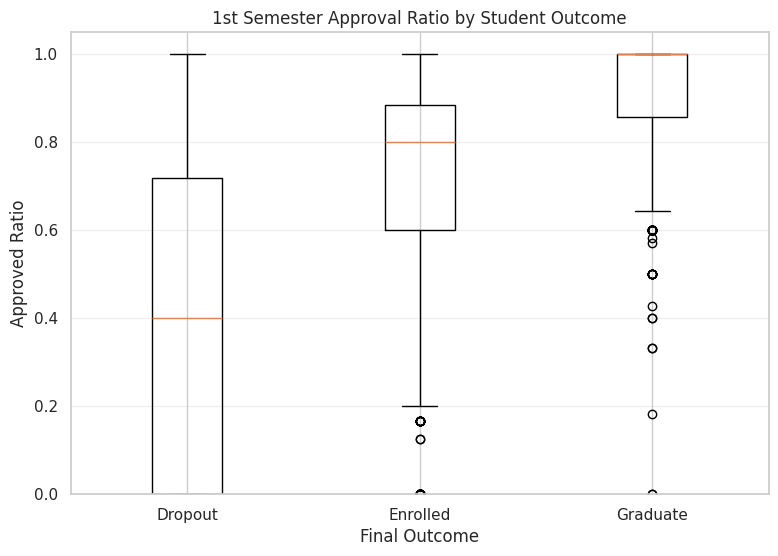

In [34]:
# 4. BOXplot - 1ST SEMESTER APPROVAL RATIO

order = ['Dropout', 'Enrolled', 'Graduate']

data_1st = [
    ratio_df.loc[
        ratio_df['Target'] == target,
        'Approved ratio 1st sem'
    ]
    for target in order
]

plt.figure(figsize=(9, 6))

plt.boxplot(
    data_1st,
    tick_labels=order
)

plt.ylabel('Approved Ratio')
plt.xlabel('Final Outcome')
plt.title('1st Semester Approval Ratio by Student Outcome')

plt.ylim(0, 1.05)
plt.grid(axis='y', alpha=0.3)

plt.show()

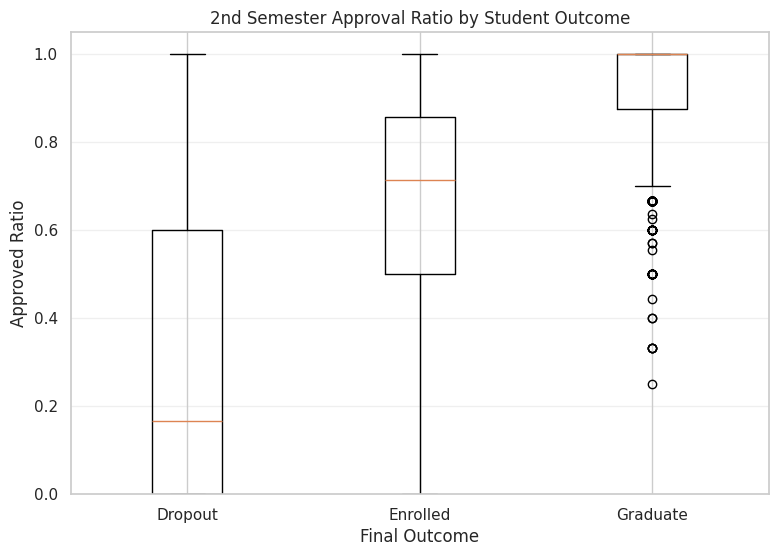

In [35]:
# 5. BOXPLOT - 2ND SEMESTER APPROVAL RATIO

data_2nd = [
    ratio_df.loc[
        ratio_df['Target'] == target,
        'Approved ratio 2nd sem'
    ]
    for target in order
]

plt.figure(figsize=(9, 6))

plt.boxplot(
    data_2nd,
    tick_labels=order
)

plt.ylabel('Approved Ratio')
plt.xlabel('Final Outcome')
plt.title('2nd Semester Approval Ratio by Student Outcome')

plt.ylim(0, 1.05)
plt.grid(axis='y', alpha=0.3)

plt.show()

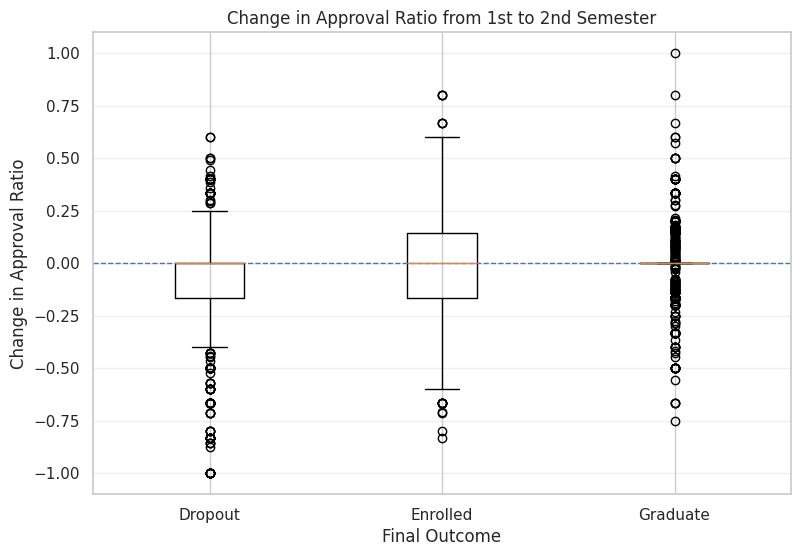

In [36]:
# 6. BOXPLOT - APPROVAL RATIO CHANGE

data_change = [
    ratio_df.loc[
        ratio_df['Target'] == target,
        'Approval ratio change'
    ]
    for target in order
]

plt.figure(figsize=(9, 6))

plt.boxplot(
    data_change,
    tick_labels=order
)

plt.axhline(
    y=0,
    linestyle='--',
    linewidth=1
)

plt.ylabel('Change in Approval Ratio')
plt.xlabel('Final Outcome')
plt.title('Change in Approval Ratio from 1st to 2nd Semester')

plt.grid(axis='y', alpha=0.3)

plt.show()

**Kruskal–Wallis test**

In [37]:
# 7. KRUSKAL-WALLIS TEST - 1ST SEMESTER

from scipy.stats import kruskal

groups_1st = [
    ratio_df.loc[
        ratio_df['Target'] == target,
        'Approved ratio 1st sem'
    ]
    for target in order
]

h_1st, p_1st = kruskal(*groups_1st)

print("=== Kruskal-Wallis Test: 1st Semester ===")
print(f"H statistic: {h_1st:.4f}")
print(f"p-value: {p_1st:.10f}")

=== Kruskal-Wallis Test: 1st Semester ===
H statistic: 1941.0841
p-value: 0.0000000000


In [38]:
# 8. KRUSKAL-WALLIS TEST - 2ND SEMESTER

groups_2nd = [
    ratio_df.loc[
        ratio_df['Target'] == target,
        'Approved ratio 2nd sem'
    ]
    for target in order
]

h_2nd, p_2nd = kruskal(*groups_2nd)

print("=== Kruskal-Wallis Test: 2nd Semester ===")
print(f"H statistic: {h_2nd:.4f}")
print(f"p-value: {p_2nd:.10f}")

=== Kruskal-Wallis Test: 2nd Semester ===
H statistic: 2324.5156
p-value: 0.0000000000


In [39]:
# 9. KRUSKAL-WALLIS TEST - SEMESTER-TO-SEMESTER CHANGE

groups_change = [
    ratio_df.loc[
        ratio_df['Target'] == target,
        'Approval ratio change'
    ]
    for target in order
]

h_change, p_change = kruskal(*groups_change)

print("=== Kruskal-Wallis Test: Approval Ratio Change ===")
print(f"H statistic: {h_change:.4f}")
print(f"p-value: {p_change:.10f}")

=== Kruskal-Wallis Test: Approval Ratio Change ===
H statistic: 178.0625
p-value: 0.0000000000


### **1st semester:**

* H = 1941.08, p < 0.0001 → strong evidence that approval ratios differ across Dropout, Enrolled, Graduate groups.

### **2nd semester:**

* H = 2324.52, p < 0.0001 → differences are even stronger in semester 2.

### **Change (1st → 2nd):**

* H = 178.06, p < 0.0001 → the amount of change also differs significantly between groups.

The three groups are **statistically distinct in both semesters**, and their trajectories are not the same.

**Dunn's test**

In [40]:
!pip install scikit-posthocs

In [41]:
import scikit_posthocs as sp

In [42]:
# 10. DUNN'S TEST - 1ST SEMESTER

dunn_1st = sp.posthoc_dunn(
    ratio_df,
    val_col='Approved ratio 1st sem',
    group_col='Target',
    p_adjust='holm'
)

print("=== Dunn's Test: 1st Semester ===")
print(dunn_1st)

=== Dunn's Test: 1st Semester ===
               Dropout      Enrolled      Graduate
Dropout   1.000000e+00  2.676585e-43  0.000000e+00
Enrolled  2.676585e-43  1.000000e+00  4.327893e-98
Graduate  0.000000e+00  4.327893e-98  1.000000e+00


* **Dropout vs Enrolled**: p ≈ 2.7e‑43 → highly significant difference.

* **Dropout vs Graduate**: p ≈ 0 → most extremely significant difference.

* **Enrolled vs Graduate**: p ≈ 4.3e‑98 → extremely significant difference.

In semester 1, all three groups differ significantly in approval ratios. Graduates are clearly stronger, dropouts weaker, enrolled in the middle.

In [43]:
# 11. DUNN'S TEST - 2ND SEMESTER

dunn_2nd = sp.posthoc_dunn(
    ratio_df,
    val_col='Approved ratio 2nd sem',
    group_col='Target',
    p_adjust='holm'
)

print("=== Dunn's Test: 2nd Semester ===")
print(dunn_2nd)

=== Dunn's Test: 2nd Semester ===
               Dropout       Enrolled       Graduate
Dropout   1.000000e+00   5.305668e-50   0.000000e+00
Enrolled  5.305668e-50   1.000000e+00  2.833212e-119
Graduate  0.000000e+00  2.833212e-119   1.000000e+00


* **Dropout vs Enrolled**: p ≈ 5.3e‑50 → highly significant difference.

* **Dropout vs Graduate**: p ≈ 0 → most extremely significant difference.

* **Enrolled vs Graduate**: p ≈ 2.8e‑119 → extremely significant difference.

In semester 2, the **differences are even stronger than semester 1**. The gap between groups widens dropouts decline further, graduates remain excellent, enrolled stay in between.

In [44]:
# 12. DUNN'S TEST - APPROVAL RATIO CHANGE

dunn_change = sp.posthoc_dunn(
    ratio_df,
    val_col='Approval ratio change',
    group_col='Target',
    p_adjust='holm'
)

print("=== Dunn's Test: Approval Ratio Change ===")
print(dunn_change)

=== Dunn's Test: Approval Ratio Change ===
               Dropout      Enrolled      Graduate
Dropout   1.000000e+00  9.084964e-08  5.914388e-40
Enrolled  9.084964e-08  1.000000e+00  2.923591e-07
Graduate  5.914388e-40  2.923591e-07  1.000000e+00


* **Dropout vs Enrolled**: p ≈ 9.1e‑08 → significant difference in change.

* **Dropout vs Graduate**: p ≈ 5.9e‑40 → extremely significant difference.

* **Enrolled vs Graduate**: p ≈ 2.9e‑07 → significant difference.

The amount of change (semester‑to‑semester trajectory) also differs across groups:

* Dropouts decline much more than others.

* Enrolled decline moderately.

* Graduates remain stable.

## **Integrated Insights**
* **Consistency across semesters**: Dunn’s tests confirm that **every pair of groups is statistically distinct** in both semesters.

* **Strengthening differences**: The p‑values in semester 2 are even smaller than semester 1, showing that the separation between groups grows over time.

* **Trajectory differences**: The change analysis shows that dropouts deteriorate significantly compared to enrolled and graduates, while graduates barely change.

### Approval ratios are predictive of final outcomes, and the **divergence between groups becomes sharper over time.**

In [45]:
# 13. KRUSKAL-WALLIS EFFECT SIZE

def epsilon_squared(H, groups):
    n = sum(len(group) for group in groups)
    k = len(groups)

    return (H - k + 1) / (n - k)


eps_1st = epsilon_squared(h_1st, groups_1st)
eps_2nd = epsilon_squared(h_2nd, groups_2nd)
eps_change = epsilon_squared(h_change, groups_change)

print("=== Effect Sizes ===")
print(f"1st semester epsilon²: {eps_1st:.4f}")
print(f"2nd semester epsilon²: {eps_2nd:.4f}")
print(f"Change epsilon²:       {eps_change:.4f}")

=== Effect Sizes ===
1st semester epsilon²: 0.4572
2nd semester epsilon²: 0.5476
Change epsilon²:       0.0415


* **1st semester**: ε² = 0.457 → large effect (group membership explains ~46% of variance).

* **2nd semester**: ε² = 0.548 → even larger effect (~55% of variance).

* **Change**: ε² = 0.042 → small effect (~4% of variance explained).

Group differences are very strong in both semesters, but the differences in change are weaker — meaning **while groups differ in average decline, the variance in individual trajectories is high.**

In [46]:
# 14. FINAL DESCRIPTIVE SUMMARY

final_summary = (
    ratio_df
    .groupby('Target', observed=False)
    .agg(
        n=('Approved ratio 1st sem', 'count'),

        first_mean=('Approved ratio 1st sem', 'mean'),
        first_median=('Approved ratio 1st sem', 'median'),

        second_mean=('Approved ratio 2nd sem', 'mean'),
        second_median=('Approved ratio 2nd sem', 'median'),

        change_mean=('Approval ratio change', 'mean'),
        change_median=('Approval ratio change', 'median')
    )
)

# Convert ratios to percentages
percentage_columns = [
    'first_mean',
    'first_median',
    'second_mean',
    'second_median',
    'change_mean',
    'change_median'
]

final_summary[percentage_columns] *= 100

print("=== Final Approval Ratio Summary ===")
print(final_summary.round(2))

=== Final Approval Ratio Summary ===
             n  first_mean  first_median  second_mean  second_median  \
Target                                                                 
Dropout   1344       40.60          40.0        31.01          16.67   
Enrolled   766       71.35          80.0        67.31          71.43   
Graduate  2134       93.50         100.0        93.21         100.00   

          change_mean  change_median  
Target                                
Dropout         -9.59            0.0  
Enrolled        -4.04            0.0  
Graduate        -0.29            0.0  


### **Integrated Insights**
**Dropouts**:

* Statistically and descriptively the weakest group.

* Large decline across semesters, many with 0 approvals.

* Strong evidence they diverge significantly from others.

**Enrolled**:

* Middle performers.

* Slight decline, but still decent medians.

* Statistically distinct from both Dropouts and Graduates.

**Graduates**:

* Consistently excellent.

* Majority at 100% approvals, negligible decline.

* Statistically distinct from both other groups with large effect sizes.

**Change analysis**:

* Confirms Dropouts decline more, Enrolled decline moderately, Graduates remain stable.

* Effect size is smaller because individual variation within groups is high.

## **3. Total approved units in first year**

In [73]:
df['Total approved first year'] = (
    pd.to_numeric(df['Curricular units 1st sem (approved)'], errors='coerce')
    +
    pd.to_numeric(df['Curricular units 2nd sem (approved)'], errors='coerce')
)

df.groupby('Target', observed=False)['Total approved first year'].describe()

,count,mean,std,min,25%,50%,75%,max
Target,,,,,,,,
Dropout,1421.0,4.491907,5.232157,0.0,0.0,3.0,8.0,33.0
Enrolled,794.0,8.376574,4.222740,0.0,6.0,8.0,11.0,27.0
Graduate,2209.0,12.409235,4.728022,0.0,10.0,12.0,14.0,43.0


* **Clear progression**: Dropouts < Enrolled < Graduates in terms of approved units.

* **Predictive signal**: The number of units approved in the first year is strongly associated with eventual outcome.

* **Risk markers**: Dropouts cluster at very low approvals (median = 3), which could serve as an early warning threshold.

* **Graduates**: High approvals (median = 12) suggest persistence and success are tied to strong early performance.

In [74]:
# Split into groups
groups_total = [
    df.loc[df['Target'] == target, 'Total approved first year']
    for target in df['Target'].unique()
]

# Kruskal–Wallis test
h_total, p_total = kruskal(*groups_total)

print("=== Kruskal-Wallis Test: Total Approved First Year ===")
print(f"H statistic: {h_total:.4f}")
print(f"p-value: {p_total:.10f}")

# Dunn’s post-hoc test with Holm correction
dunn_total = sp.posthoc_dunn(
    df,
    val_col='Total approved first year',
    group_col='Target',
    p_adjust='holm'
)

print("\n=== Dunn's Test: Total Approved First Year ===")
print(dunn_total)

=== Kruskal-Wallis Test: Total Approved First Year ===
H statistic: 1824.1501
p-value: 0.0000000000

=== Dunn's Test: Total Approved First Year ===
               Dropout      Enrolled      Graduate
Dropout   1.000000e+00  8.702580e-41  0.000000e+00
Enrolled  8.702580e-41  1.000000e+00  3.153923e-91
Graduate  0.000000e+00  3.153923e-91  1.000000e+00


* **Dropout vs Enrolled**: p ≈ 8.7e‑41 → highly significant difference.

* **Dropout vs Graduate**: p ≈ 0 → extremely significant difference.

* **Enrolled vs Graduate**: p ≈ 3.2e‑91 → extremely significant difference.

Every pair of groups is statistically distinct. Graduates approve far more units than enrolled, and enrolled approve far more than dropouts.

In [75]:
def epsilon_squared(H, groups):
    n = sum(len(g) for g in groups)
    k = len(groups)
    return (H - k + 1) / (n - k)

eps_total = epsilon_squared(h_total, groups_total)

print("\n=== Effect Size (epsilon²) ===")
print(f"Total approved first year epsilon²: {eps_total:.4f}")


=== Effect Size (epsilon²) ===
Total approved first year epsilon²: 0.4122


* The number of units approved in the first year is **strongly predictive of eventual outcome**.

* Differences are **not only statistically significant but also practically large** (ε² > 0.4).

* This metric could be used as an **early warning signal**: students with very low approvals are at high risk of dropout, while those with high approvals are likely to graduate.

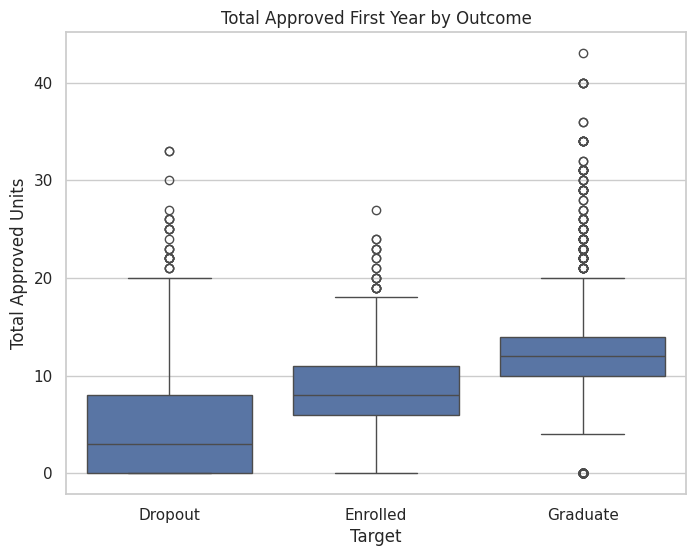

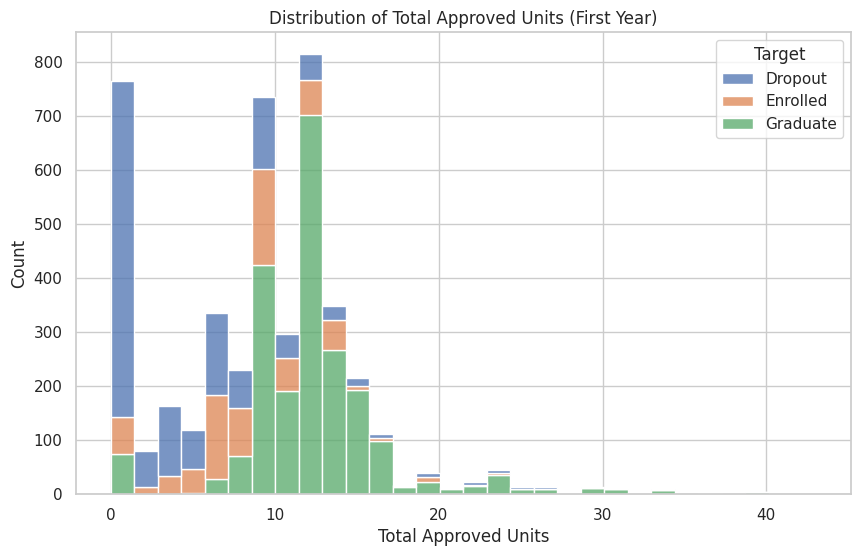

In [76]:
# Boxplot
plt.figure(figsize=(8,6))
sns.boxplot(x='Target', y='Total approved first year', data=df)
plt.title("Total Approved First Year by Outcome")
plt.ylabel("Total Approved Units")
plt.show()

# Histogram (stacked by group)
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Total approved first year', hue='Target',
             multiple='stack', bins=30)
plt.title("Distribution of Total Approved Units (First Year)")
plt.xlabel("Total Approved Units")
plt.ylabel("Count")
plt.show()

## **Statistical Summary**

In [47]:
print("--- Numerical Features Summary ---")
display(df.describe())

print("\n--- Categorical Features Summary ---")
display(df.describe(include=['object', 'category']))

--- Numerical Features Summary ---


,Application order,Previous qualification (grade),Admission grade,Age at enrollment,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),...,Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Approved ratio 1st sem,Approved ratio 2nd sem,No enrollment both semesters
count,4424.0,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4244.000000,4244.000000,4424.000000
mean,1.727848,132.613314,126.978119,23.265145,0.709991,6.270570,8.299051,4.706600,10.640822,0.137658,...,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969,0.727484,0.688364,0.040687
std,1.313793,13.188332,14.482001,7.587816,2.360507,2.480178,4.179106,3.094238,4.843663,0.690880,...,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935,0.342821,0.365513,0.197587
min,0.0,95.000000,95.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000,0.000000,0.000000,0.000000
25%,1.0,125.000000,117.900000,19.000000,0.000000,5.000000,6.000000,3.000000,11.000000,0.000000,...,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000,0.600000,0.500000,0.000000
50%,1.0,133.100000,126.100000,20.000000,0.000000,6.000000,8.000000,5.000000,12.285714,0.000000,...,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000,0.857143,0.833333,0.000000
75%,2.0,140.000000,134.800000,25.000000,0.000000,7.000000,10.000000,6.000000,13.400000,0.000000,...,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000,1.000000,1.000000,0.000000
max,9.0,190.000000,190.000000,70.000000,20.000000,26.000000,45.000000,26.000000,18.875000,12.000000,...,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000,1.000000,1.000000,1.000000



--- Categorical Features Summary ---


,Marital status,Application mode,Course,Daytime/evening attendance,Previous qualification,Nationality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,International,Target,First choice
count,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424
unique,6,18,17,2,17,21,29,34,32,46,2,2,2,2,2,2,2,3,2
top,Single,1st Phase - General Contingent,Nursing,Daytime,Secondary Education,Portuguese,Secondary Education - 12th Year of Schooling o...,Basic Education 1st Cycle (4th/5th Year) or Eq...,Unskilled Workers,Unskilled Workers,Yes,No,No,Yes,Female,No,No,Graduate,Not first choice
freq,3919,1708,766,3941,3717,4314,1069,1209,1577,1010,2426,4373,3921,3896,2868,3325,4314,2209,4423


**Target Variable Analysis**

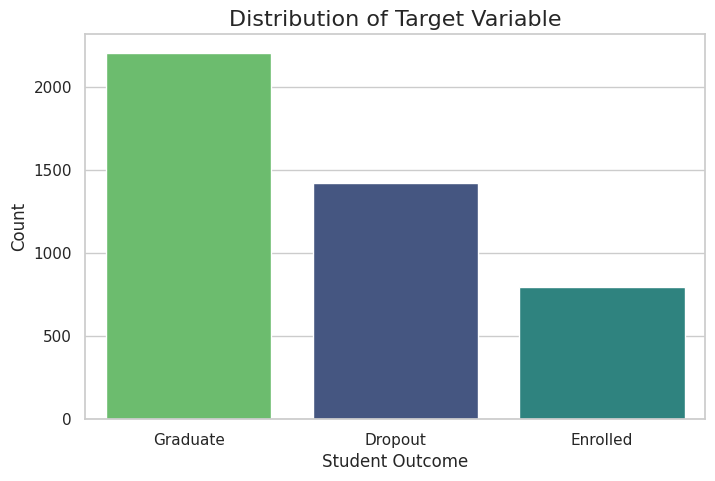

Target Variable Percentages:


,proportion
Target,
Graduate,49.932188
Dropout,32.120253
Enrolled,17.947559


In [48]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Target', hue='Target', palette='viridis', legend=False, order=df['Target'].value_counts().index)
plt.title('Distribution of Target Variable', fontsize=16)
plt.xlabel('Student Outcome', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

# Calculating percentages
target_counts = df['Target'].value_counts(normalize=True) * 100
print("Target Variable Percentages:")
display(target_counts)

**Separating Features by Type**

In [49]:
X_num = df.select_dtypes(include=[np.number]).columns.drop('Target', errors='ignore')
X_cat = df.select_dtypes(exclude=[np.number]).columns.drop('Target', errors='ignore')

print(f"Number of Numerical Features: {len(X_num)}")
print(f"Number of Categorical Features: {len(X_cat)}")

Number of Numerical Features: 22
Number of Categorical Features: 18


**Univariate Analysis (Numerical Features)**

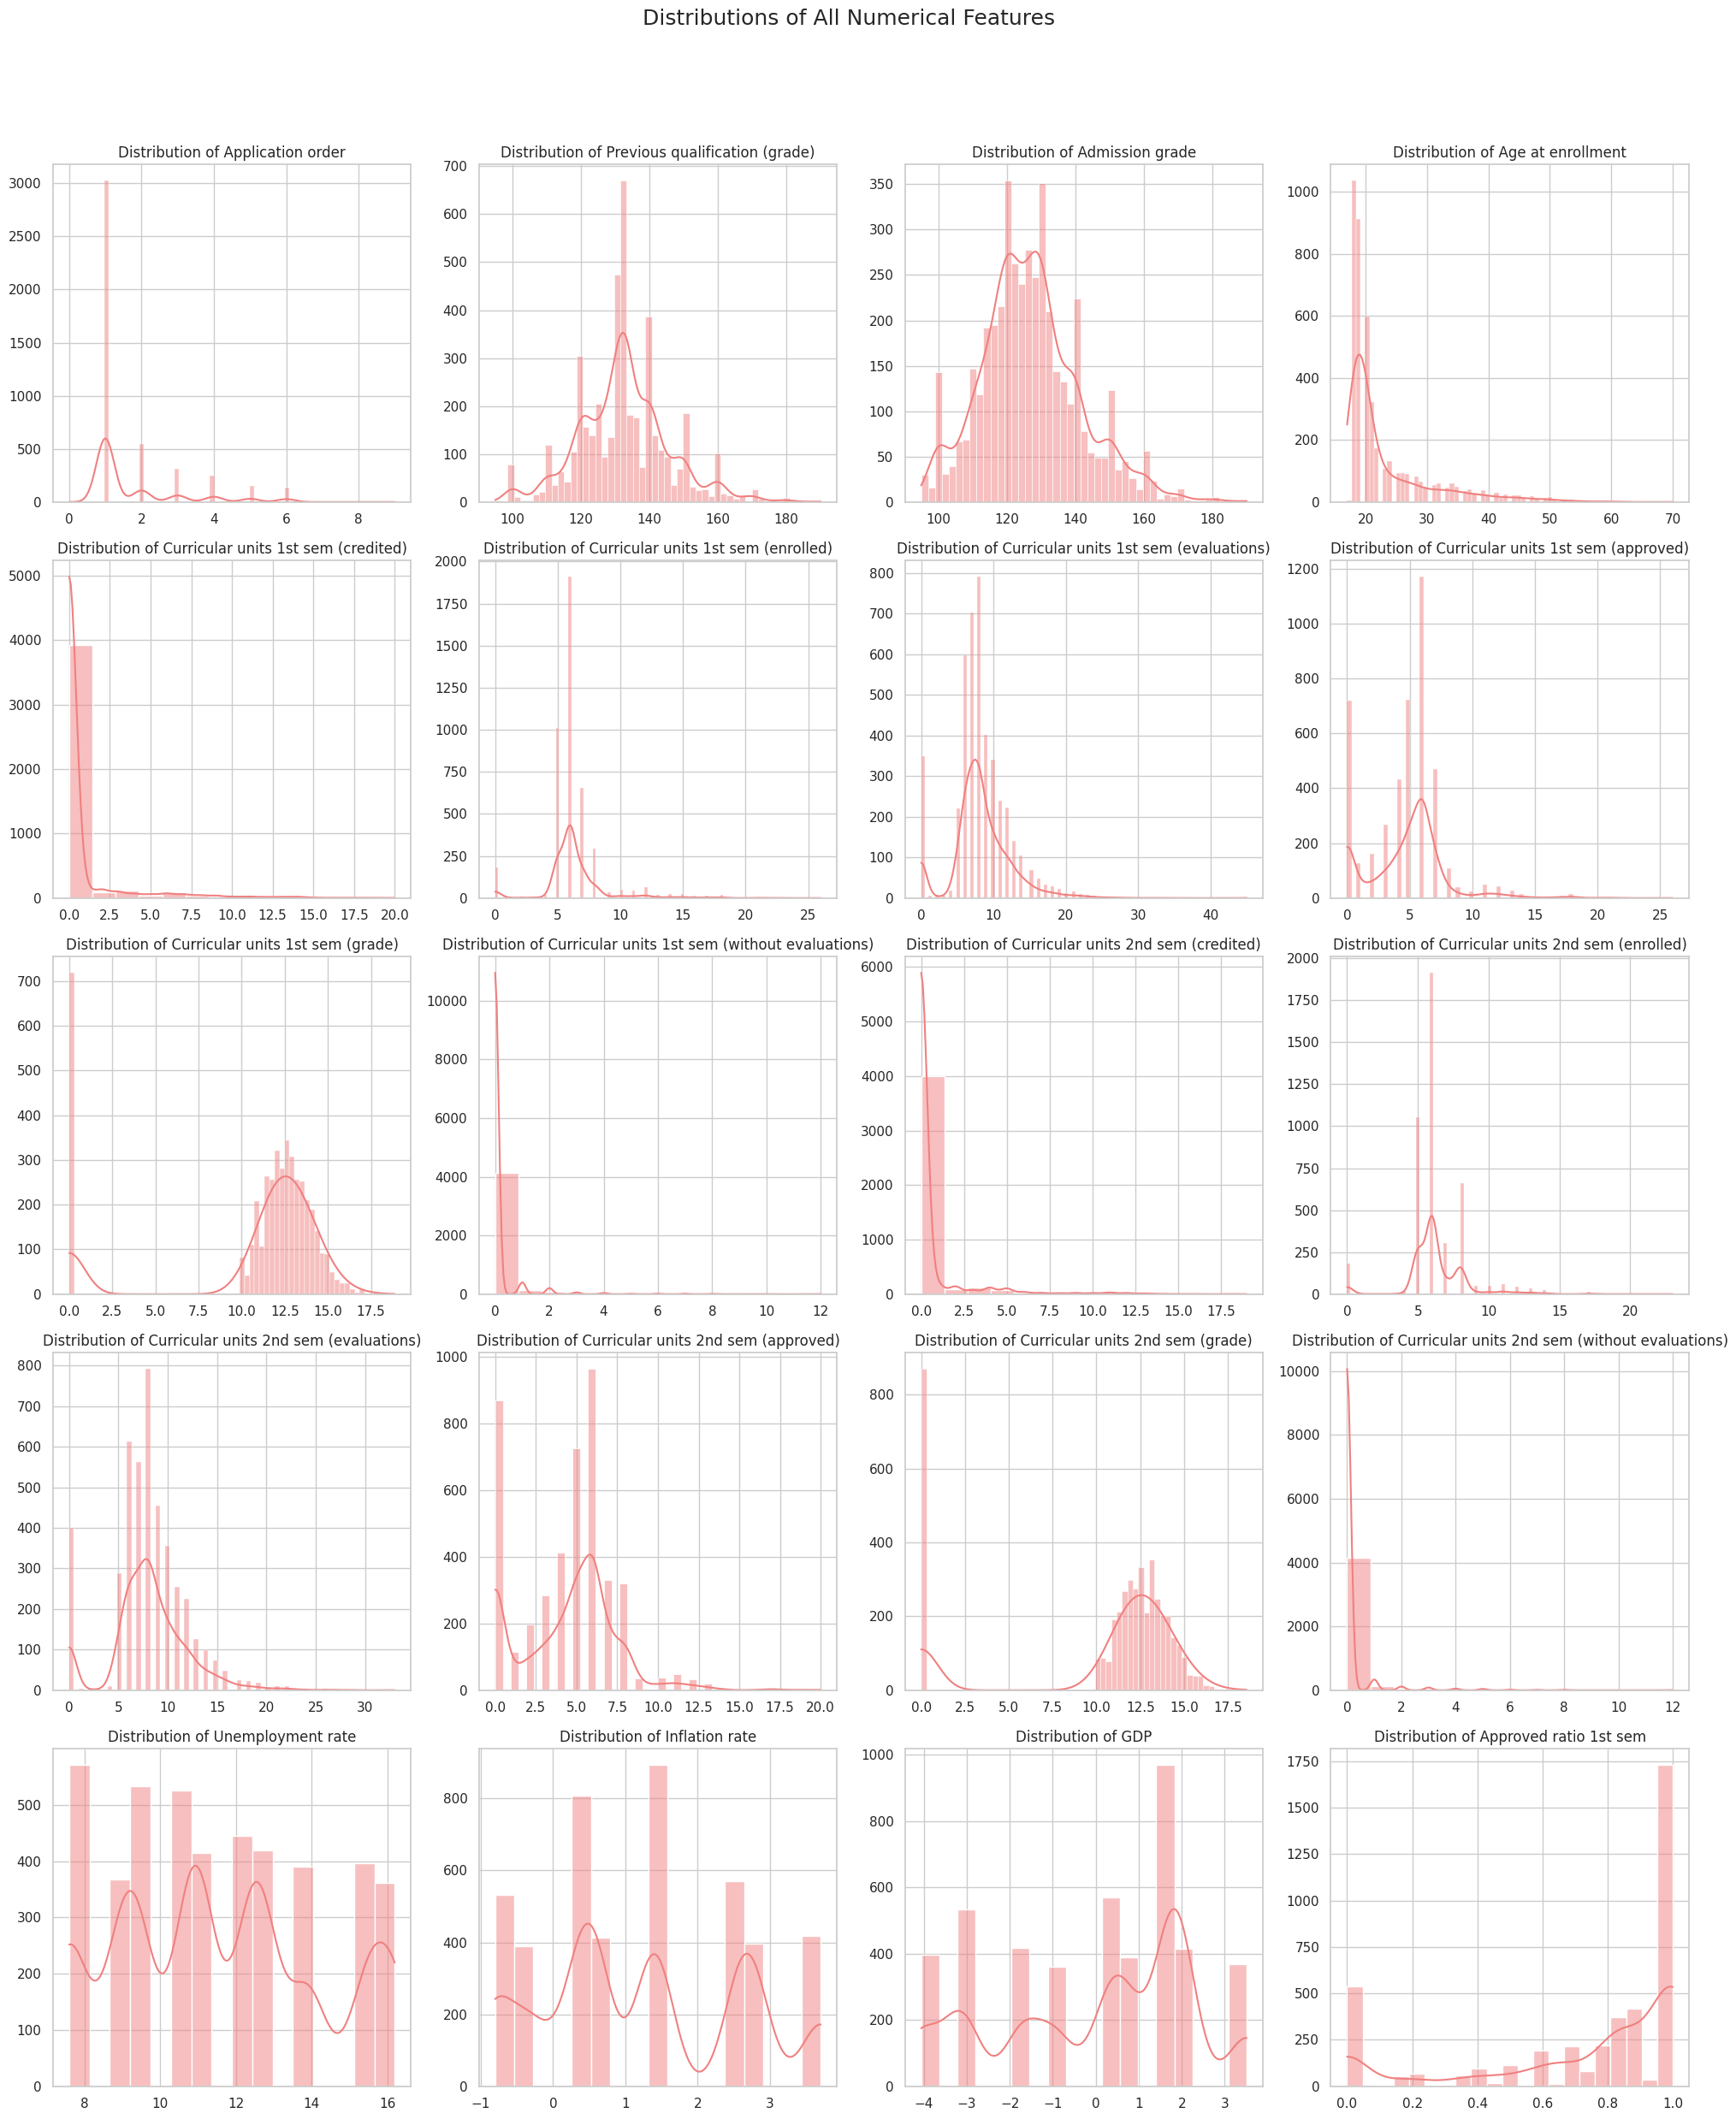

In [50]:
# Ploting all numerical features in a larger grid
# Create a 4x5 grid for 19 features (one will be empty)
fig, axes = plt.subplots(5, 4, figsize=(20, 25))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(X_num):
    if i < len(axes): # Ensure we don't go out of bounds if X_num is smaller than axes
        sns.histplot(df[col], kde=True, ax=axes[i], color='lightcoral')
        axes[i].set_title(f'Distribution of {col}', fontsize=12)
        axes[i].set_xlabel('') # Clear x-label to prevent overlap
        axes[i].set_ylabel('') # Clear y-label to prevent overlap

# Remove any unused subplots
for j in range(len(X_num), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distributions of All Numerical Features', fontsize=18, y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to make space for suptitle
plt.show()

**Univariate Analysis (Categorical Features)**

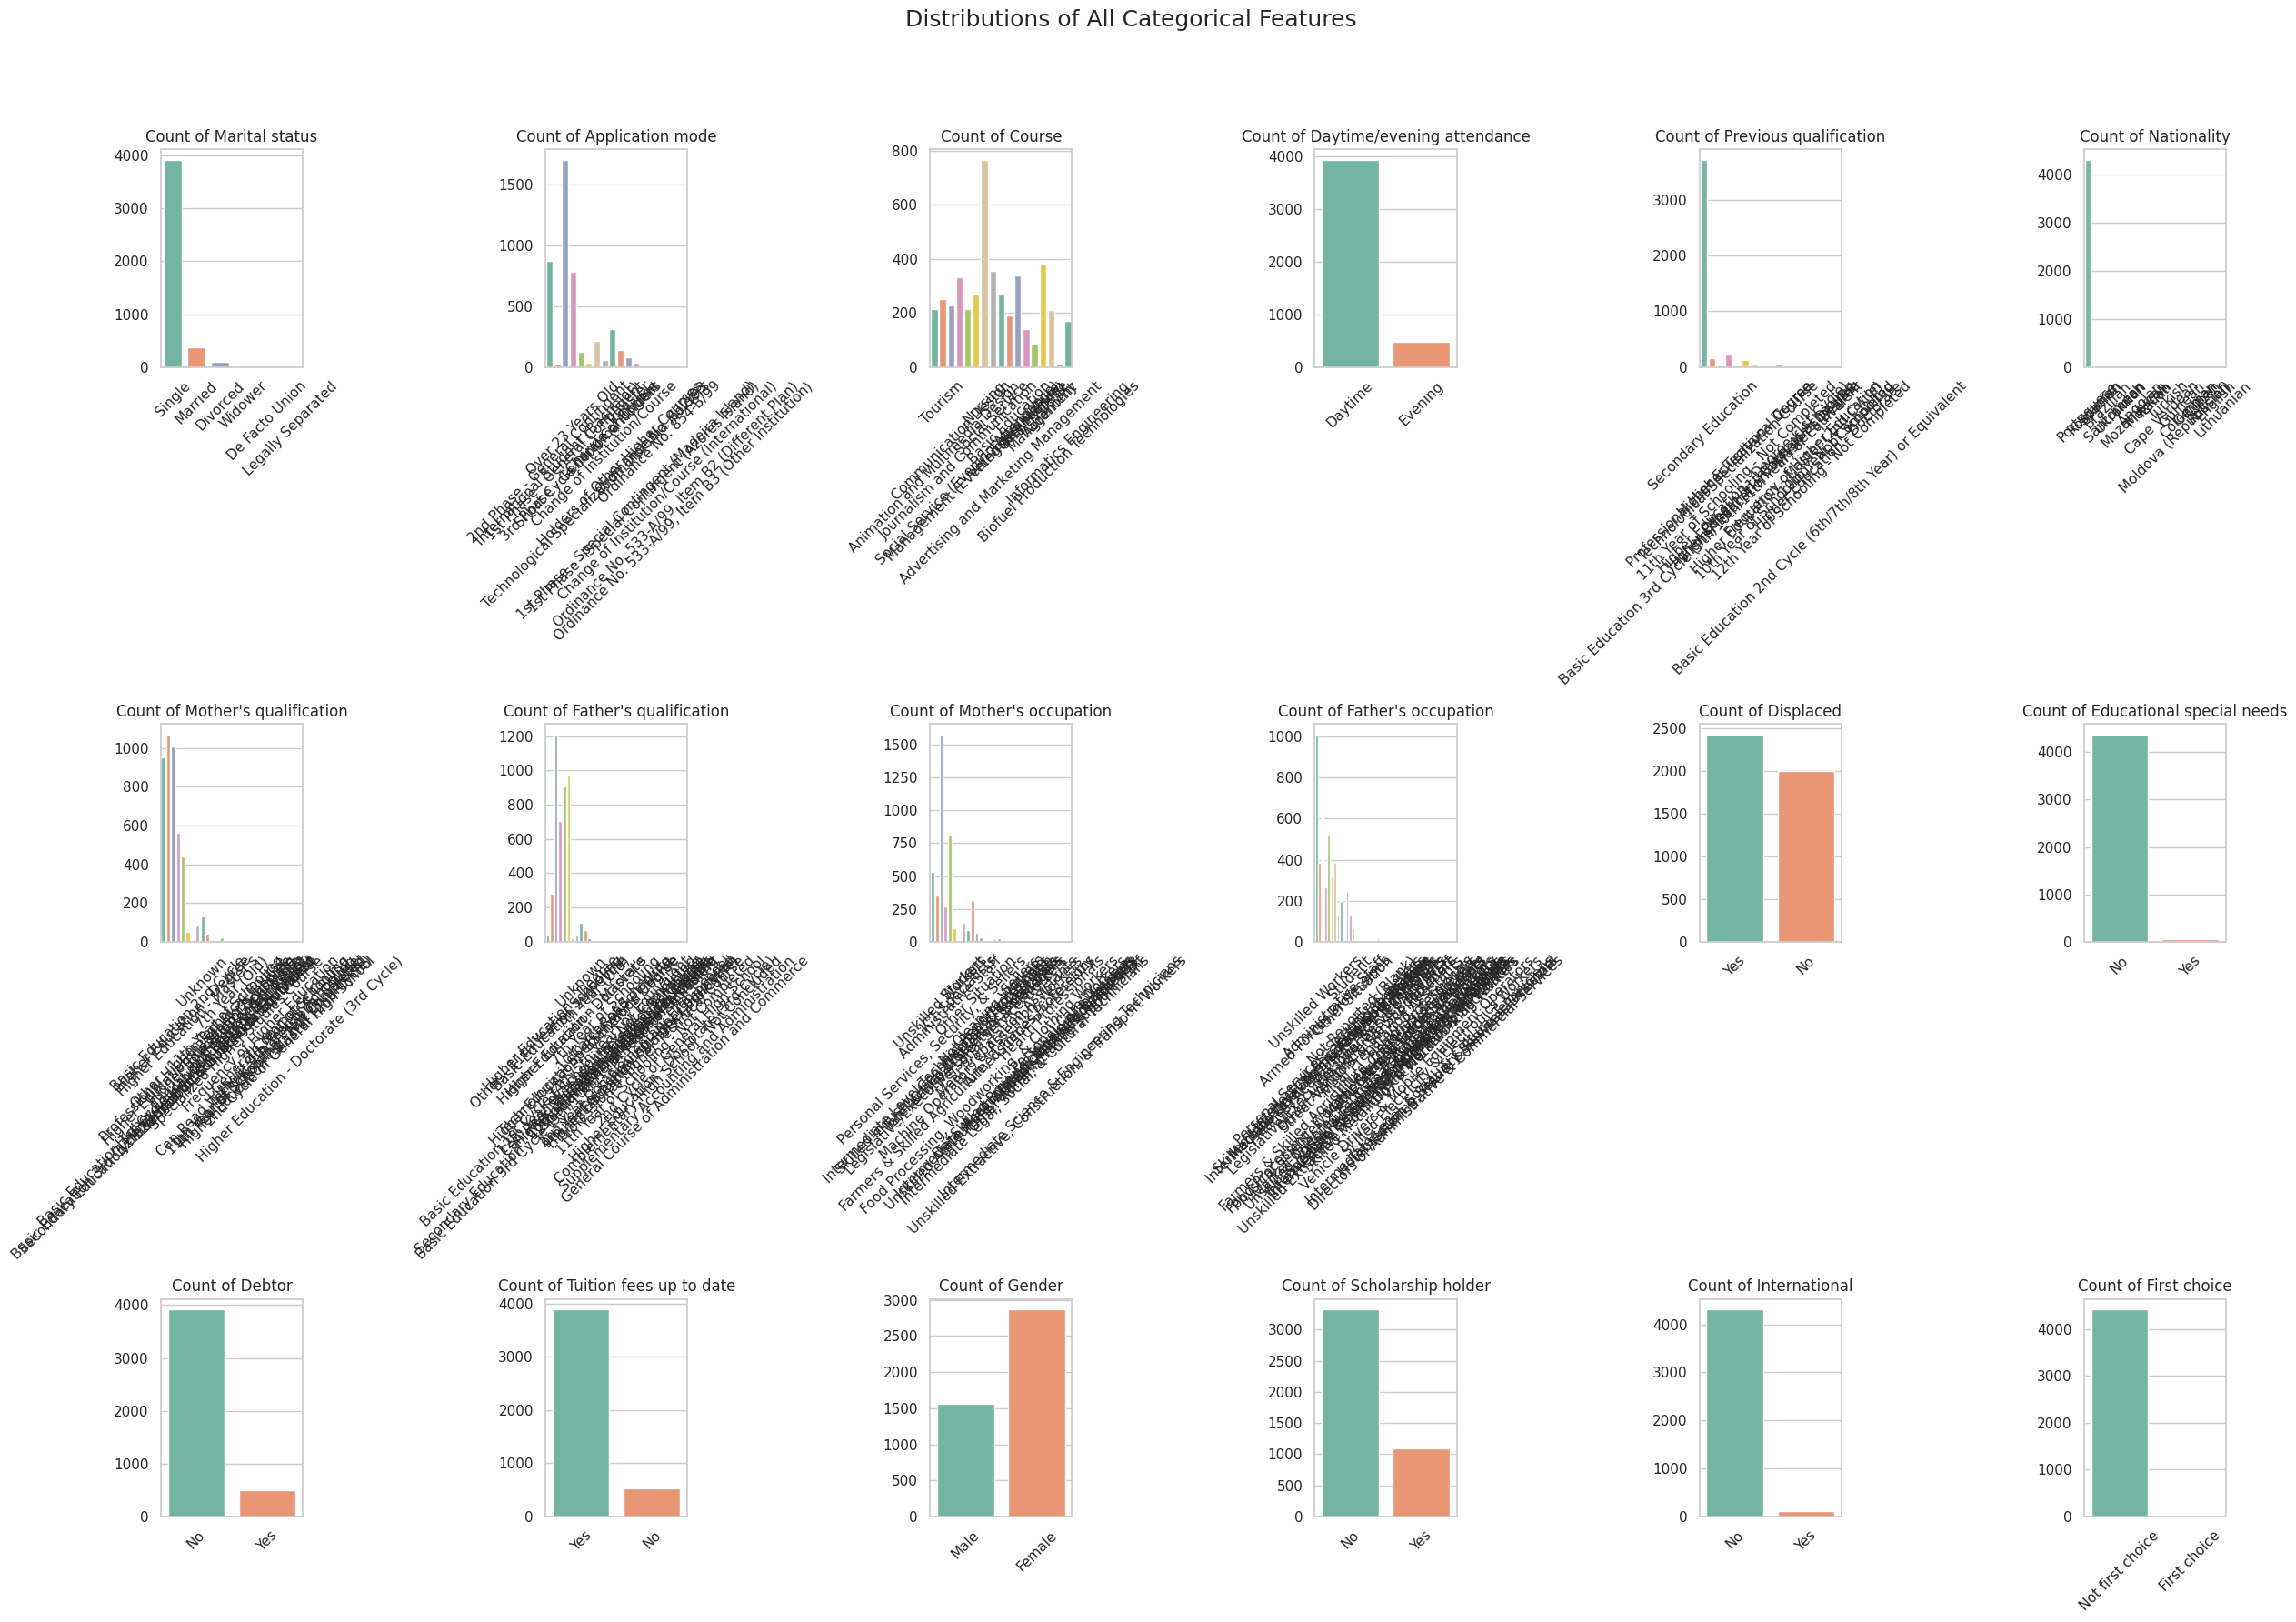

In [51]:
# Plotting all categorical features in a larger grid
# Create a 3x6 grid for 17 features (one will be empty)
fig, axes = plt.subplots(3, 6, figsize=(25, 18)) # Adjust figsize as needed
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(X_cat):
    if i < len(axes): # Ensure we don't go out of bounds if X_cat is smaller than axes
        sns.countplot(data=df, x=col, ax=axes[i], palette='Set2', hue=col, legend=False)
        axes[i].set_title(f'Count of {col}', fontsize=12)
        axes[i].set_xlabel('') # Clear x-label to prevent overlap
        axes[i].set_ylabel('') # Clear y-label to prevent overlap
        axes[i].tick_params(axis='x', rotation=45) # Rotate labels so they don't overlap

# Remove any unused subplots
for j in range(len(X_cat), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distributions of All Categorical Features', fontsize=18, y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to make space for suptitle
plt.show()

**Bivariate Analysis (Correlation Heatmap)**

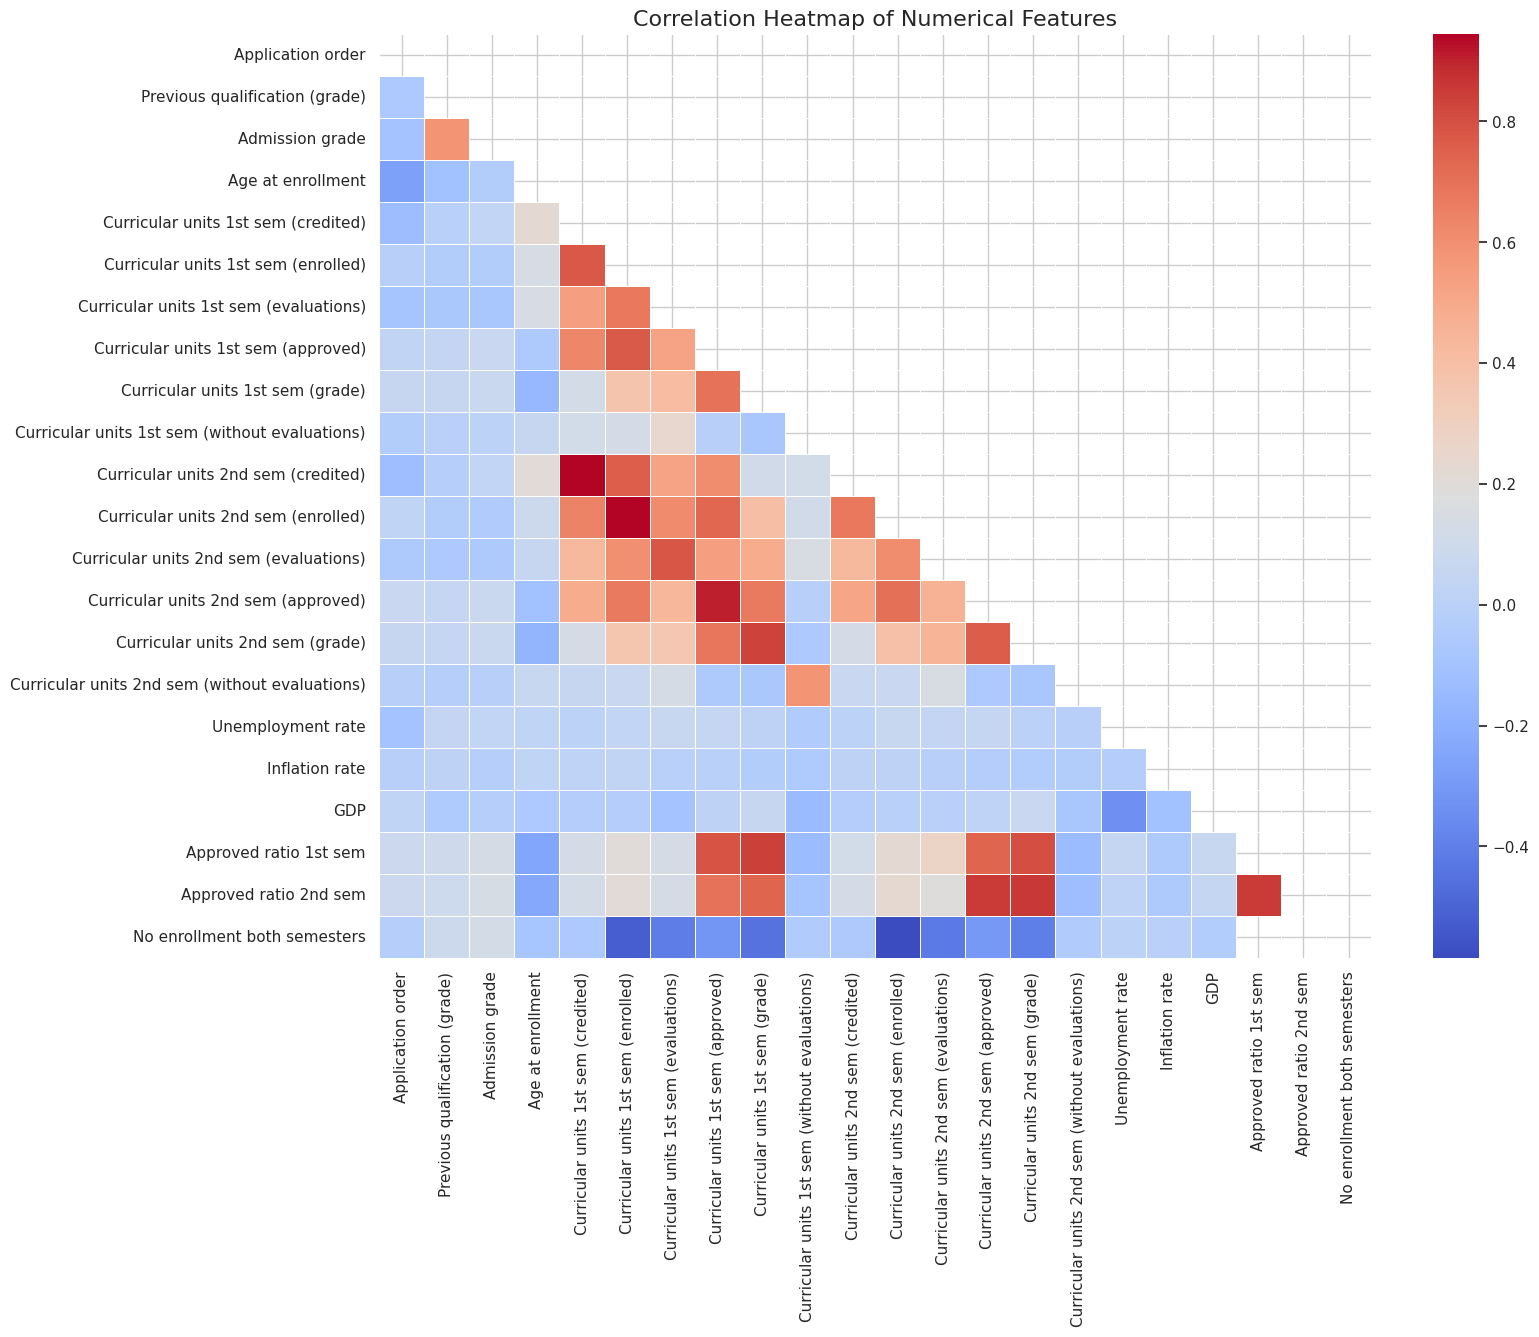

In [52]:
plt.figure(figsize=(16, 12))
correlation_matrix = df[X_num].corr()

# Creating a mask to hide the upper triangle (since it's redundant)
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.show()

**Feature vs Target Correlation**

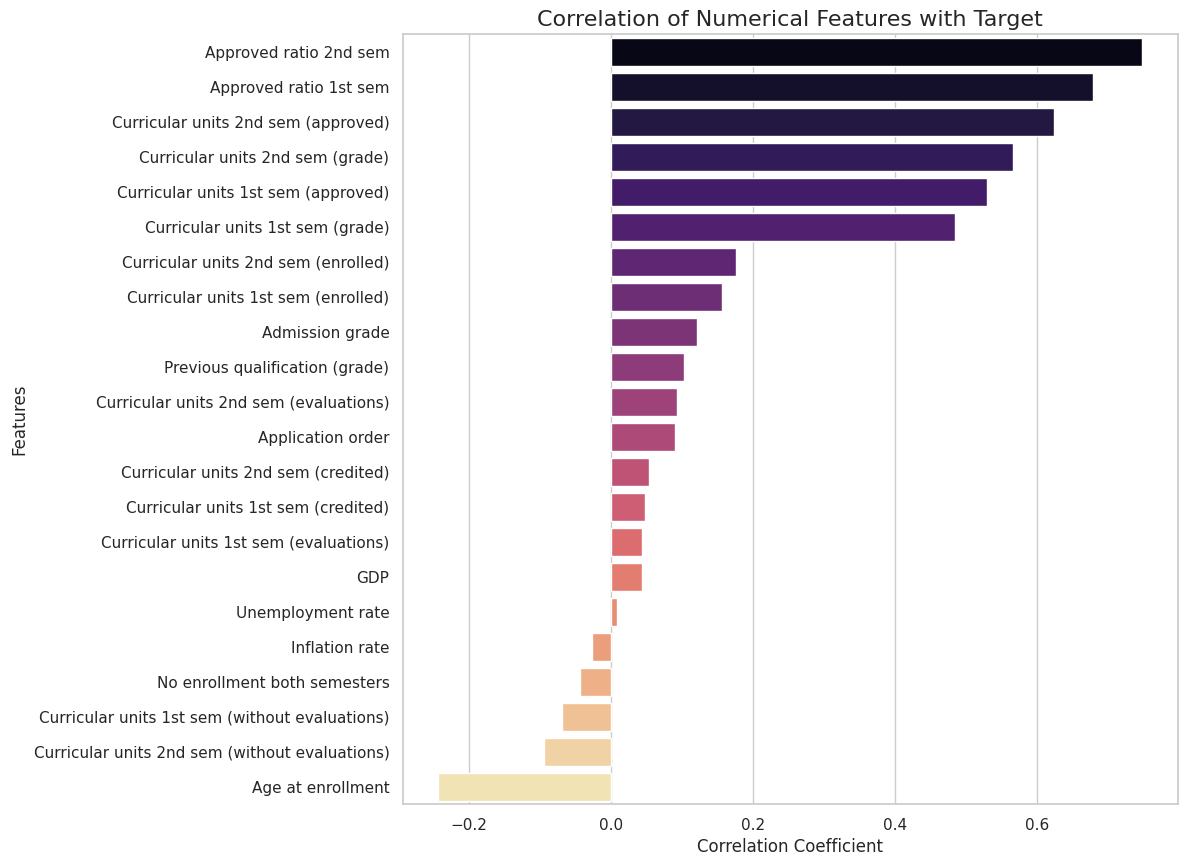

In [53]:
# Temporarily encoding Target to numbers for correlation math
target_map = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
df['Target_Encoded'] = df['Target'].map(target_map)

# Calculating correlation of all numerical features with the Target
target_corr = df[X_num].corrwith(df['Target_Encoded']).sort_values(ascending=False)

plt.figure(figsize=(10, 10))
sns.barplot(x=target_corr.values, y=target_corr.index, palette='magma', hue=target_corr.index, legend=False)
plt.title('Correlation of Numerical Features with Target', fontsize=16)
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.show()

**Outlier Detection(Numerical Features)**

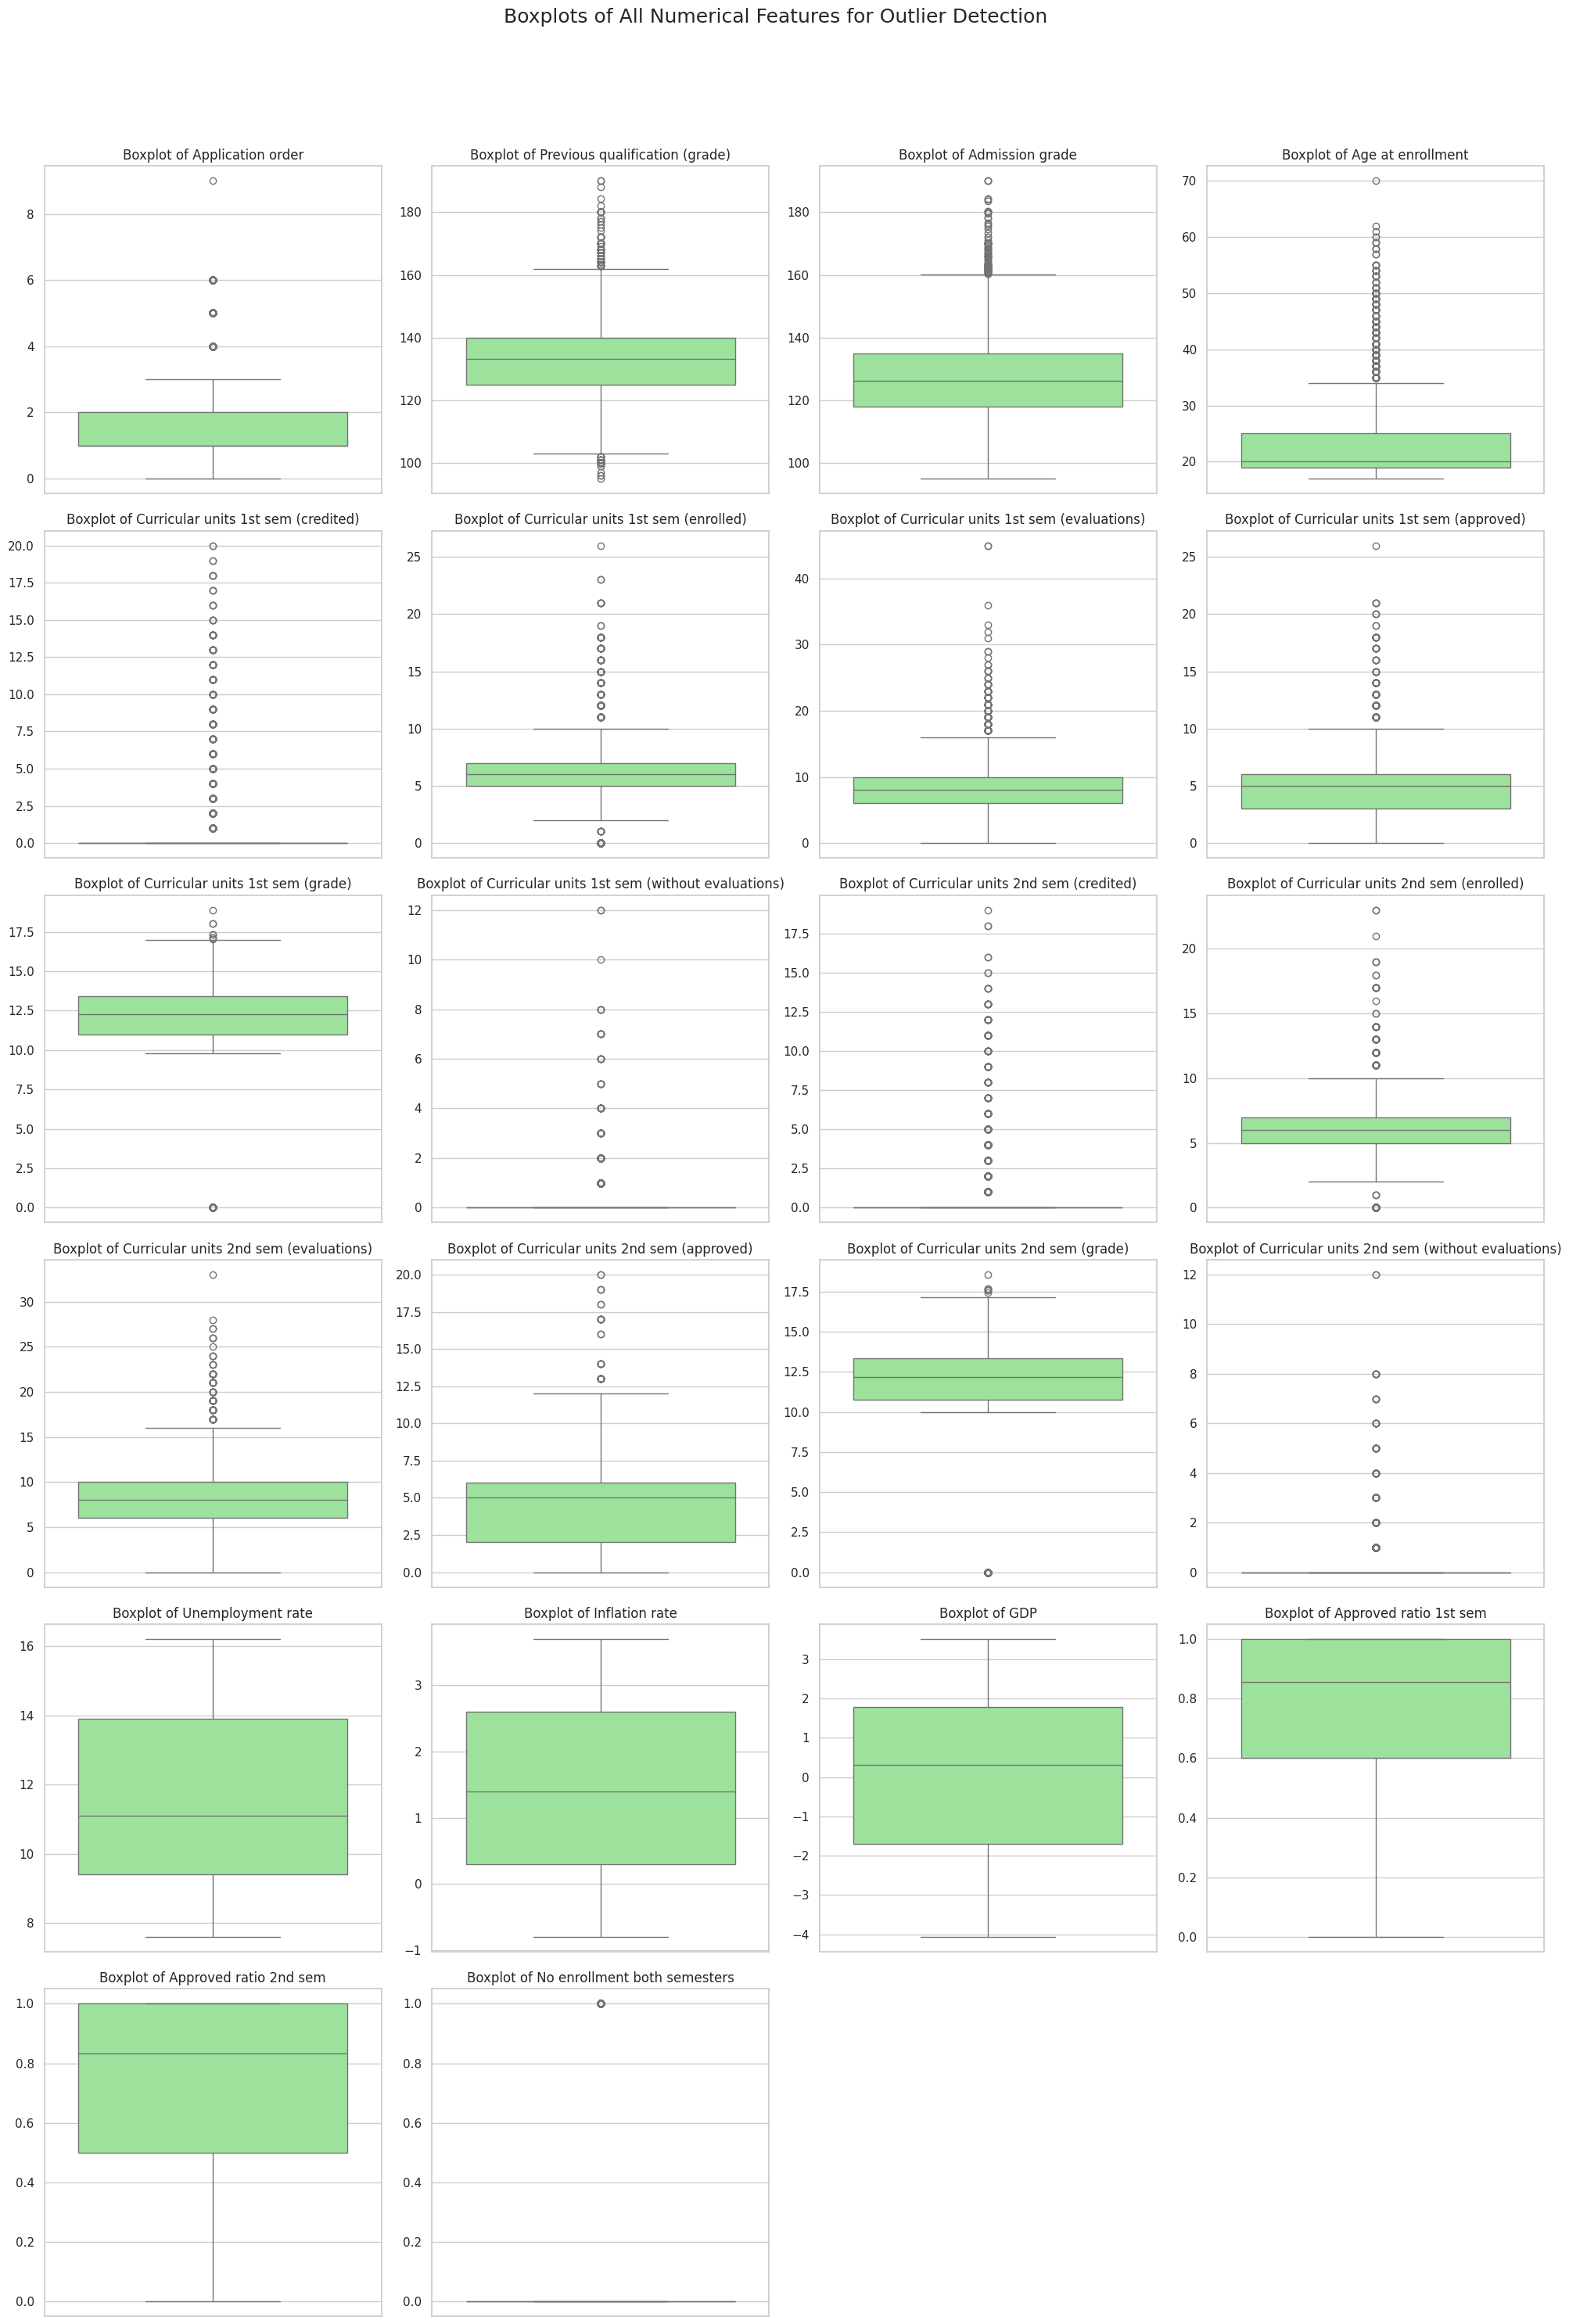

In [54]:
num_features = len(X_num)
rows = (num_features + 3) // 4  # Calculate rows needed for a 4-column layout

fig, axes = plt.subplots(rows, 4, figsize=(20, 5 * rows))
axes = axes.flatten()

for i, col in enumerate(X_num):
    if i < len(axes): # Ensure we don't go out of bounds
        sns.boxplot(data=df, y=col, ax=axes[i], color='lightgreen')
        axes[i].set_title(f'Boxplot of {col}', fontsize=12)
        axes[i].set_ylabel('') # Clear y-label to prevent overlap

# Remove any unused subplots
for j in range(num_features, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Boxplots of All Numerical Features for Outlier Detection', fontsize=18, y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to make space for suptitle
plt.show()